# 03 - Mortality Prediction and Model Analysis

This notebook reproduces the predictive modeling pipeline described in the Methodology chapter. It includes baseline model comparison, probability calibration, class imbalance experiments, final model optimization, the analysis of the relationship between predicted mortality risk and chronicity labels, and model explainability.

**Objectives**:
- Compare multiple machine learning algorithms for one-year mortality prediction.
- Assess probability calibration techniques.
- Evaluate different class imbalance handling strategies.
- Perform expanded hyperparameter tuning and threshold optimization.
- Analyze the relationship between predicted mortality risk and chronicity labels.
- Interpret model predictions using SHAP values.
- Evaluate model performance across sexes.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
from utils import clean_columns
from utils_modeling import stratified_CV, hyperparameter_tune, select_threshold_for_recall, evaluate_model, plot_pr_roc_auc, calibrate_model, calibration_curve_plot

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

import shap
from scipy.stats import mannwhitneyu, kruskal

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping
from catboost import CatBoostClassifier
import joblib

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

## 1. Data Preparation

The final patient-level dataset is loaded predictive modeling:

In [9]:
data = pd.read_csv('data/dataset.csv')
print(f'Shape of the dataset: {data.shape}')
data = clean_columns(data)
data.head()

Shape of the dataset: (55979, 161)


,id_cip_actual,sexe,situacio,cronic,gma_plng,gma_pniv,grup_edat_75_80,grup_edat_80_85,grup_edat_85_90,grup_edat_major_90,...,risc_vital_previsible_propia,risc_vital_previsible_altres,sense_risc_vital_professional_sanitari,sense_risc_vital_propia,total_urg,first_urg,last_urg,std_urg,recent_urg,days_since_last_urg
0,2,0,0,NO,0.021,2.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,1,0,NO,0.000,0.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,5,1,0,NO,0.000,0.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,7,0,0,NO,0.021,2.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,1,NO,0.000,0.0,1,0,0,0,...,0,0,0,0,1,318,318,0,1,47


Chronicity labels and GMA-related variables are excluded from training to avoid information leakage: 

In [10]:
pred_label = data['situacio']
chronic_labels = data[['MACA', 'PCC']]
data_2 = data.drop(columns=['situacio', 'MACA', 'PCC', 'gma_pniv', 'gma_plng', 'id_cip_actual', 'cronic'])

In [11]:
# Define data and predictive label
X = data_2.copy()
y = pred_label

Data is split into training (64%), validation (16%), and test (20%) sets using stratified sampling to preserve the original class distribution.

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    stratify=y_temp,
    random_state=42
)

In [18]:
X_train.to_csv('train_data/X_train.csv', index=False)
y_train.to_csv('train_data/y_train.csv', index=False)

X_val.to_csv('train_data/X_val.csv', index=False)
y_val.to_csv('train_data/y_val.csv', index=False)

X_test.to_csv('train_data/X_test.csv', index=False)
y_test.to_csv('train_data/y_test.csv', index=False)

In [19]:
print('Imbalanced dataset:\n', y.value_counts())
print('\nImbalance ratio: ', (y.value_counts()[0] / y.value_counts()[1]))

Imbalanced dataset:
 situacio
0    53171
1     2808
Name: count, dtype: int64

Imbalance ratio:  18.93554131054131


In [4]:
X_train = pd.read_csv('train_data/X_train.csv')
y_train = pd.read_csv('train_data/y_train.csv')

X_val = pd.read_csv('train_data/X_val.csv')
y_val = pd.read_csv('train_data/y_val.csv')

X_test = pd.read_csv('train_data/X_test.csv')
y_test = pd.read_csv('train_data/y_test.csv')

## 2. Model and Hyperparamater Definition

The machine learning algorithms and their corresponding hyperparameter search spaces are defined.   
Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost are evaluated under the same experimental framework.

In [5]:
lr_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            solver='liblinear',
            max_iter=5000,
            random_state=42
        ))
    ])

rf_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

xgboost_model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='aucpr'
    )

lgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1
)

catboost_model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    thread_count=1
)

In [6]:
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
}

param_grid_rf = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

param_grid_xgb = {
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 0.5, 1]
}

param_grid_lgbm = {
    'n_estimators': [200, 400],
    'learning_rate': [0.01, 0.05],
    'num_leaves': [31, 50],
    'max_depth': [-1, 5],
    'subsample': [0.7, 0.8]
}

param_grid_cat = {
    'depth': [4, 6],
    'learning_rate': [0.05],
    'iterations': [200],
    'l2_leaf_reg': [3]
}

## 3. Baseline Model Comparasion

The objective of this experiment is to compare the predictive performance of different model families before applying additional optimization strategies.  
Models are evaluated using cross-validation, hyperparameter tuning, and threshold optimization, with PR-AUC used as the primary model selection criterion.

In [19]:
baseline_models = {
    'Logistic Regression' : lr_model,
    'Random Forest' : rf_model,
    'XGBoost' : xgboost_model,
    'LGBM' : lgbm_model,
    'CatBoost' : catboost_model
}

param_grids = {
    'Logistic Regression' : param_grid_lr,
    'Random Forest' : param_grid_rf,
    'XGBoost' : param_grid_xgb,
    'LGBM' : param_grid_lgbm,
    'CatBoost' : param_grid_cat
}


------ Logistic Regression ------

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98     10634
           1       0.56      0.70      0.62       562

    accuracy                           0.96     11196
   macro avg       0.77      0.84      0.80     11196
weighted avg       0.96      0.96      0.96     11196



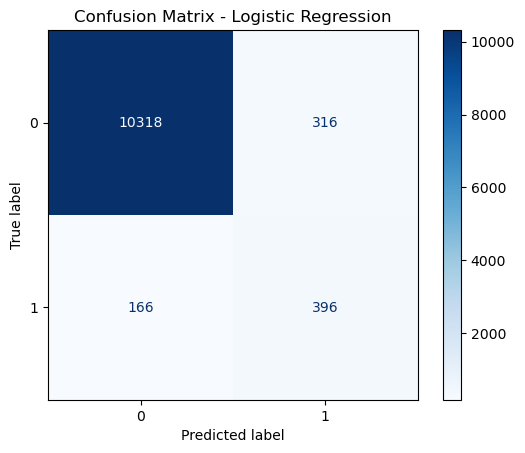

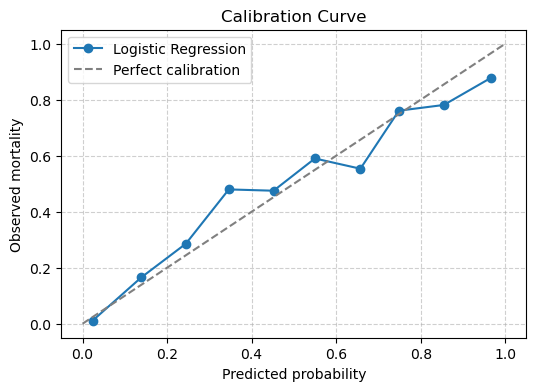

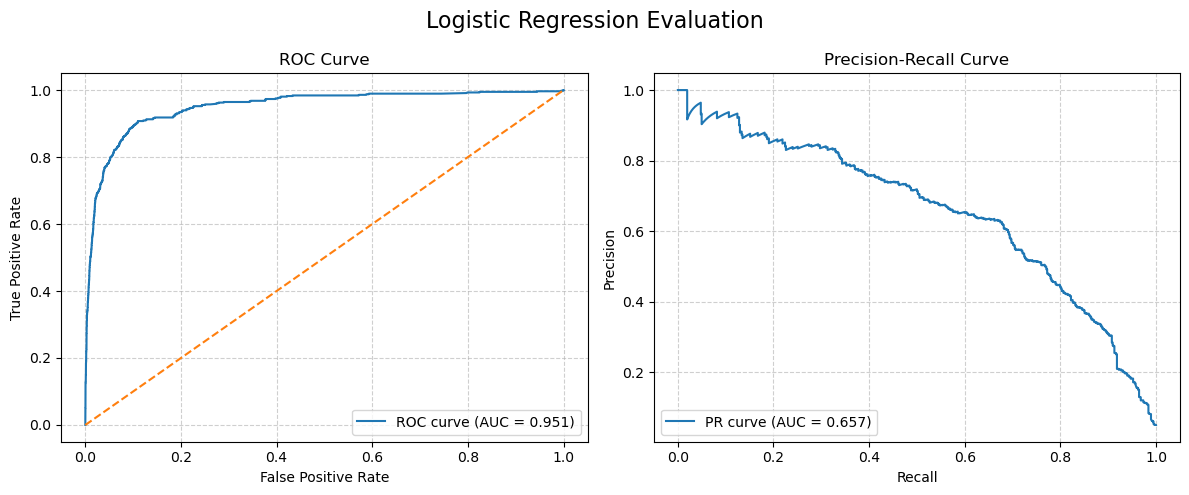


------ Random Forest ------

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98     10634
           1       0.59      0.70      0.64       562

    accuracy                           0.96     11196
   macro avg       0.79      0.84      0.81     11196
weighted avg       0.96      0.96      0.96     11196



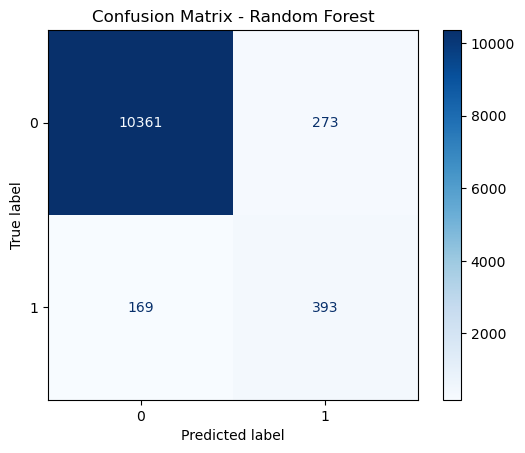

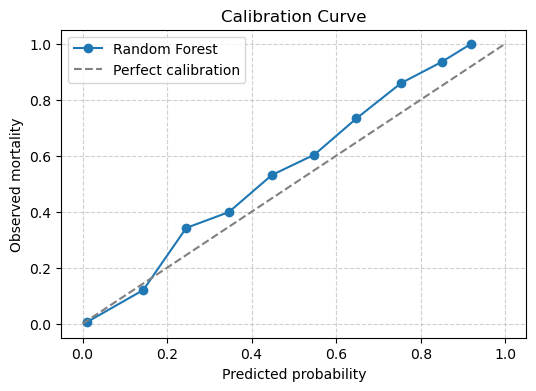

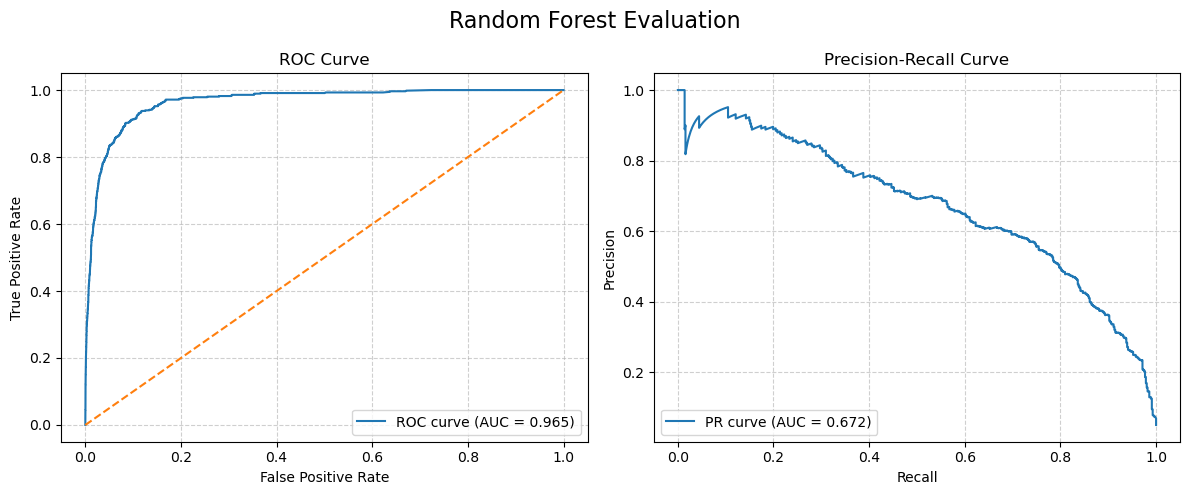


------ XGBoost ------

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98     10634
           1       0.62      0.73      0.67       562

    accuracy                           0.96     11196
   macro avg       0.80      0.85      0.83     11196
weighted avg       0.97      0.96      0.97     11196



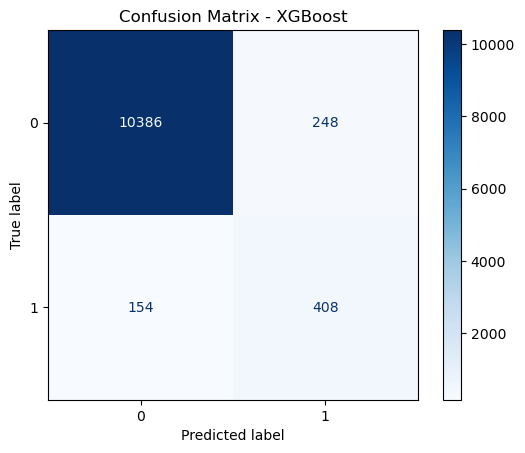

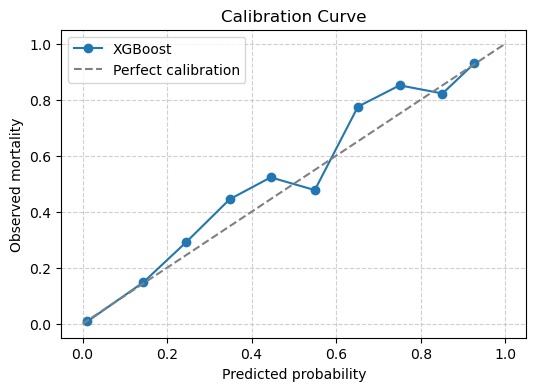

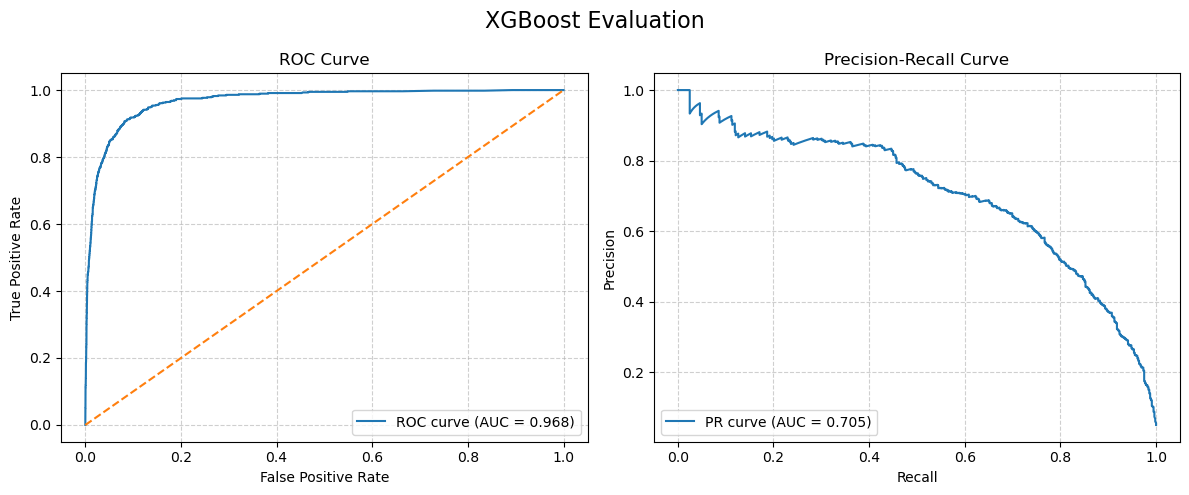


------ LGBM ------

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     10634
           1       0.66      0.70      0.68       562

    accuracy                           0.97     11196
   macro avg       0.82      0.84      0.83     11196
weighted avg       0.97      0.97      0.97     11196



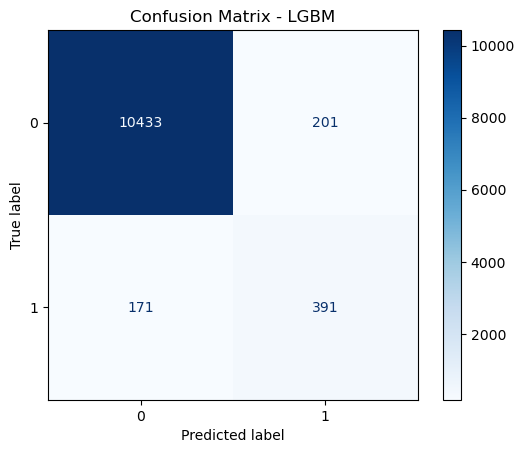

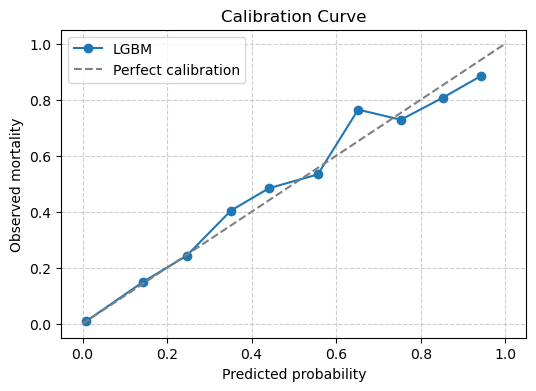

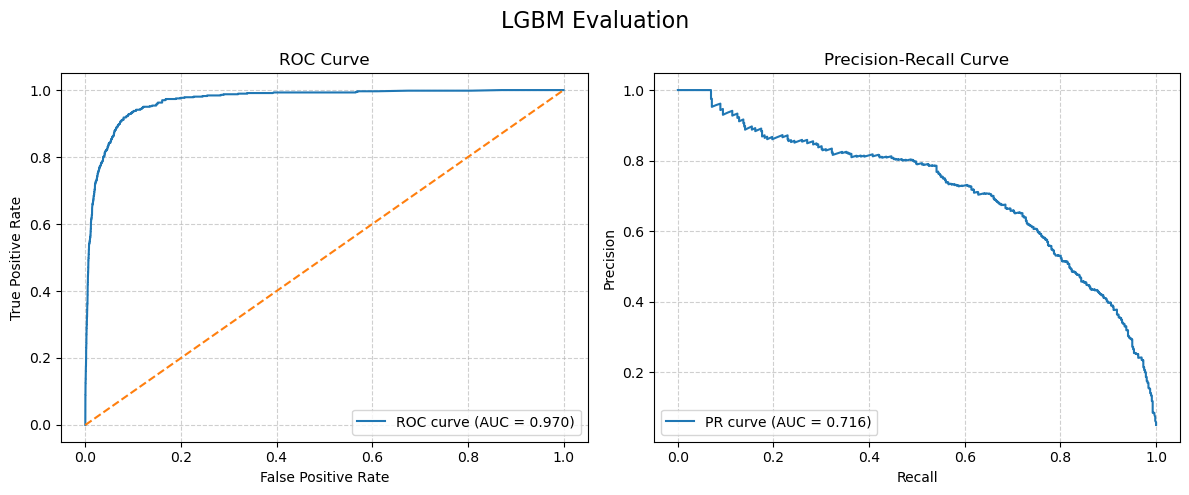


------ CatBoost ------

Fitting 5 folds for each of 2 candidates, totalling 10 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98     10634
           1       0.60      0.71      0.65       562

    accuracy                           0.96     11196
   macro avg       0.79      0.84      0.82     11196
weighted avg       0.97      0.96      0.96     11196



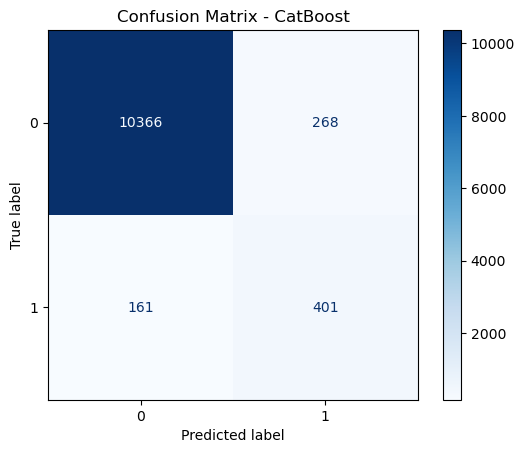

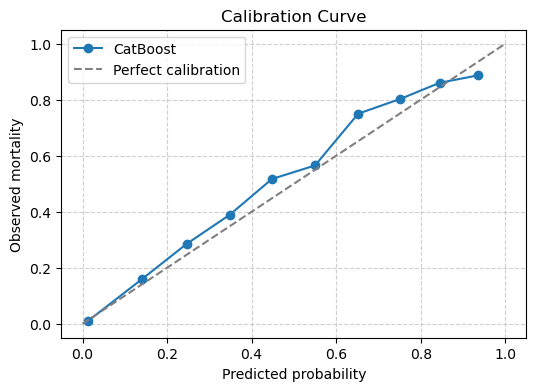

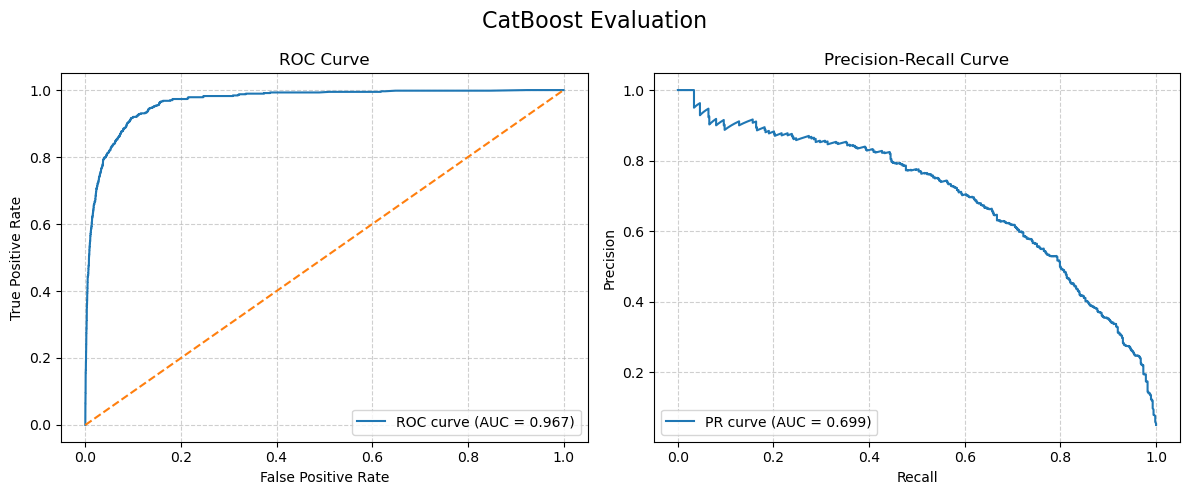

In [20]:
# Train and predict basline models

target_recall = 0.7
results_baseline = []

for name, model in baseline_models.items():

    print(f"\n------ {name} ------\n")

    # Stratified Cross-Validation
    cv_pr_auc, cv_roc_auc = stratified_CV(model, X_train, y_train, n_splits=3)

    # Hyperparamater tuning
    param_grid = param_grids[name]
    best_score, best_params, best_model = hyperparameter_tune(model, param_grid, X_train, y_train, iters=50)

    # Train the model
    best_model.fit(X_train, y_train)

    # Save model
    joblib.dump(best_model, f"saved_models/baseline/{name}_baseline.pkl")

    # Threshold tunning
    probs_val = best_model.predict_proba(X_val)[:,1]
    threshold = select_threshold_for_recall(y_val, probs_val, target_recall)

    # Predictions
    probs_test = best_model.predict_proba(X_test)[:,1]
    y_pred = (probs_test >= threshold).astype(int)    

    # Evaluate
    roc_auc, pr_auc, precision, recall, f1, brier, flag_rate = evaluate_model(y_test, probs_test, y_pred, name)

    results_baseline.append({
        'Model': name,
        'CV_PR_AUC': cv_pr_auc,
        'CV_ROC_AUC': cv_roc_auc,
        'TEST_PR_AUC': pr_auc,
        'TEST_ROC_AUC': roc_auc,
        'Recall': recall,
        'Precision': precision,
        'F1': f1,
        'Brier': brier,
        'Threshold': threshold,
        'Flag_rate': flag_rate,
        'Best_Params': best_params
    })

    calibration_curve_plot(probs_test, y_test, name)
    plot_pr_roc_auc(roc_auc, pr_auc, y_test, probs_test, name)

df_results_baseline = pd.DataFrame(results_baseline)
df_results_baseline.to_csv('model_results/results_baseline.csv', index=False)

In [25]:
df_results_baseline

,Model,CV_PR_AUC,CV_ROC_AUC,TEST_PR_AUC,TEST_ROC_AUC,Recall,Precision,F1,Brier,Threshold,Flag_rate,Best_Params
0,Logistic Regression,0.598792,0.929548,0.657122,0.950607,0.704626,0.556180,0.621664,0.026864,0.191729,0.063594,{'model__C': 0.01}
1,Random Forest,0.657251,0.951703,0.672477,0.965243,0.699288,0.590090,0.640065,0.026167,0.254572,0.059486,"{'n_estimators': 400, 'min_samples_leaf': 5, '..."
2,XGBoost,0.685831,0.959741,0.704737,0.967948,0.725979,0.621951,0.669951,0.024139,0.248120,0.058592,"{'subsample': 0.7, 'min_child_weight': 3, 'max..."
3,LGBM,0.686341,0.960747,0.715720,0.970113,0.695730,0.660473,0.677643,0.023598,0.301406,0.052876,"{'subsample': 0.7, 'num_leaves': 31, 'n_estima..."
4,CatBoost,0.691513,0.960450,0.699334,0.966650,0.713523,0.599402,0.651503,0.024563,0.224660,0.059753,"{'learning_rate': 0.05, 'l2_leaf_reg': 3, 'ite..."


## 4. Calibration Analysis of Top-Performing Models

Probability calibration is applied to the best-performing models to improve the agreement between predicted and observed mortality probabilities.  
Both isotonic regression and sigmoid calibration are evaluated using calibration curves and Brier scores.

In [26]:
finalist_models = {
    'XGBoost' : xgboost_model,
    'LGBM' : lgbm_model,
    'CatBoost' : catboost_model
}

finalist_param_grids = {
    'XGBoost' : param_grid_xgb,
    'LGBM' : param_grid_lgbm,
    'CatBoost' : param_grid_cat
}


------ XGBoost ------

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98     10634
           1       0.62      0.73      0.67       562

    accuracy                           0.96     11196
   macro avg       0.80      0.85      0.83     11196
weighted avg       0.97      0.96      0.97     11196



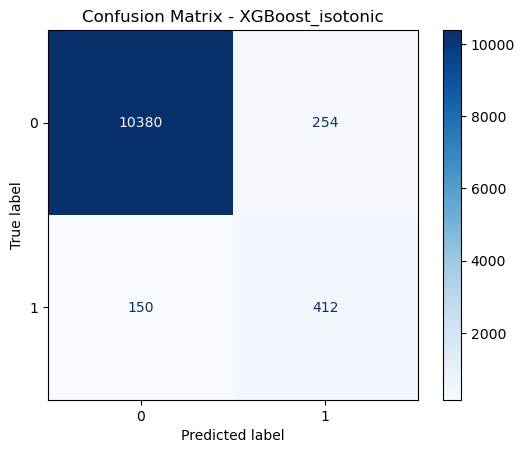

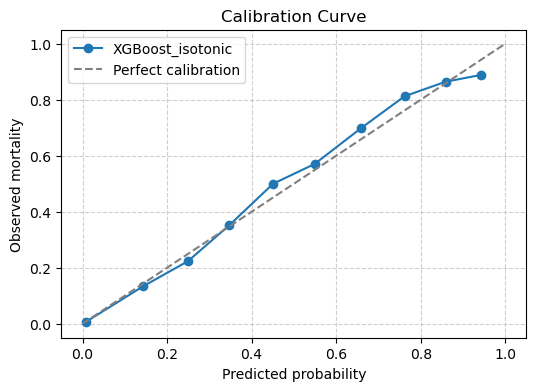

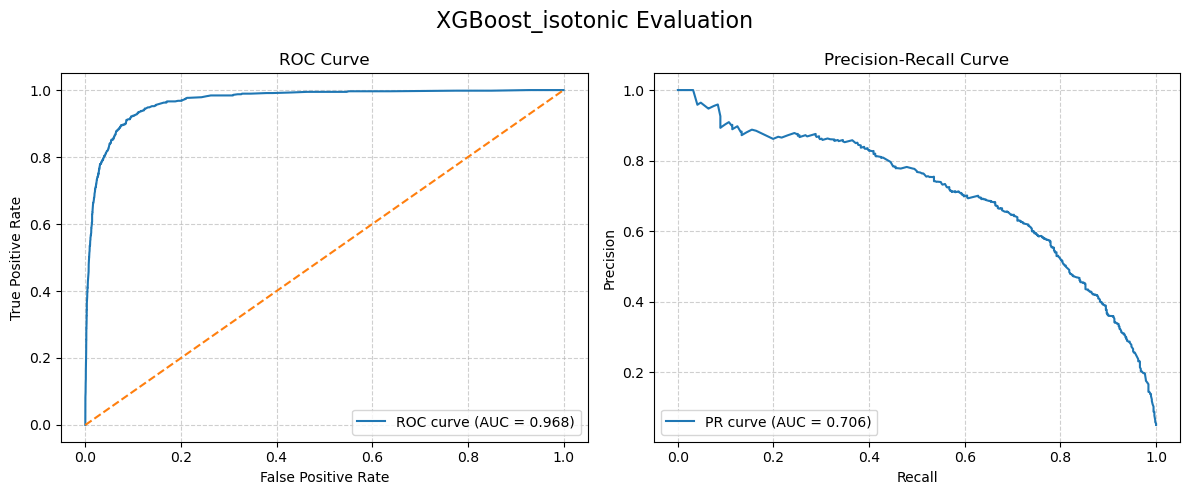


Classification report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98     10634
           1       0.61      0.73      0.67       562

    accuracy                           0.96     11196
   macro avg       0.80      0.85      0.82     11196
weighted avg       0.97      0.96      0.96     11196



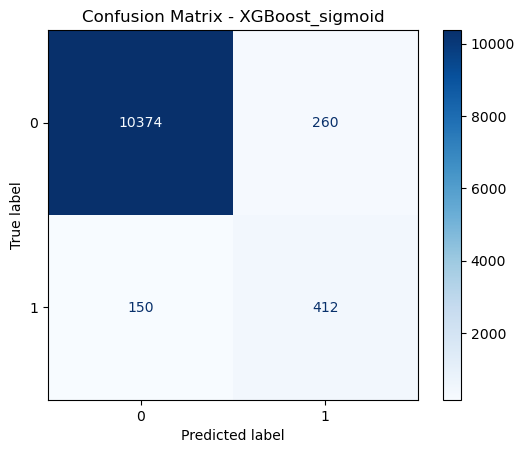

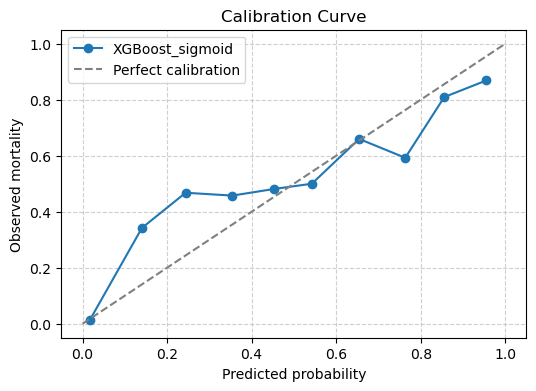

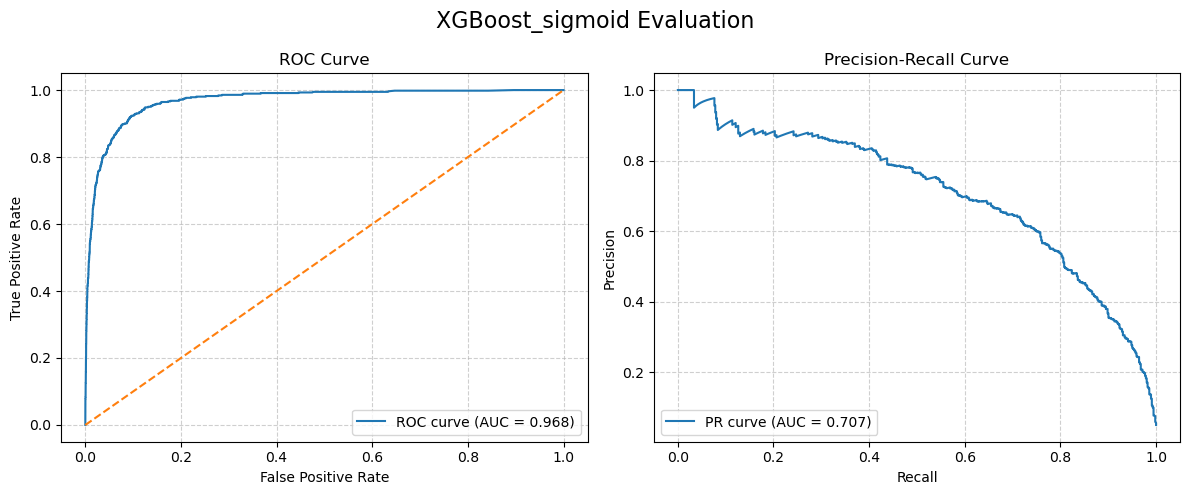


------ LGBM ------

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     10634
           1       0.64      0.69      0.66       562

    accuracy                           0.96     11196
   macro avg       0.81      0.84      0.82     11196
weighted avg       0.97      0.96      0.97     11196



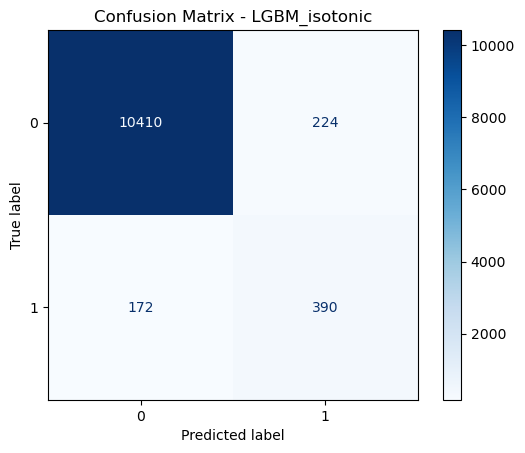

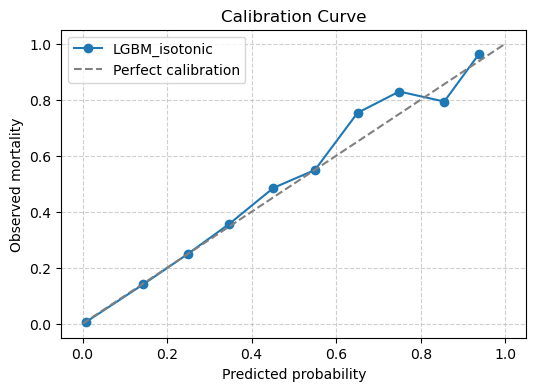

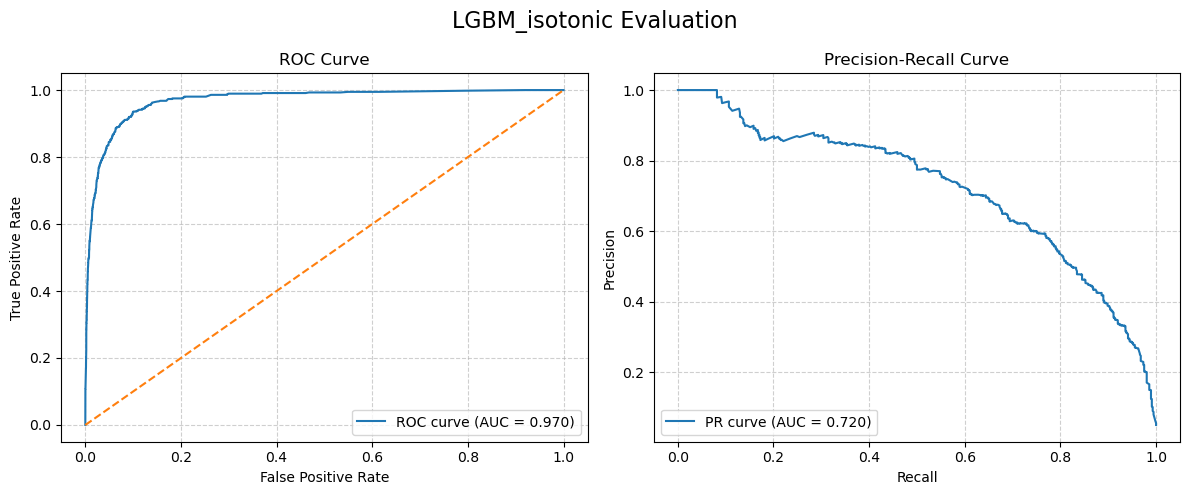


Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     10634
           1       0.65      0.69      0.67       562

    accuracy                           0.97     11196
   macro avg       0.82      0.84      0.83     11196
weighted avg       0.97      0.97      0.97     11196



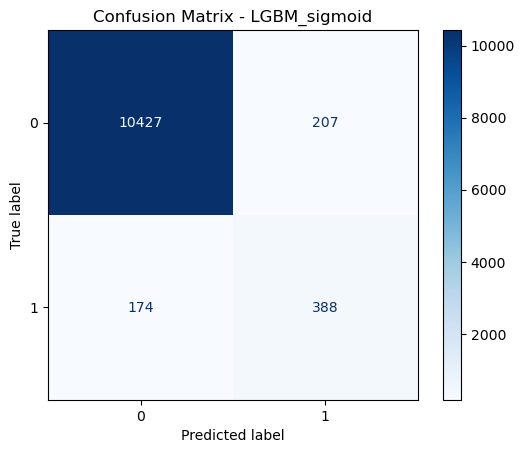

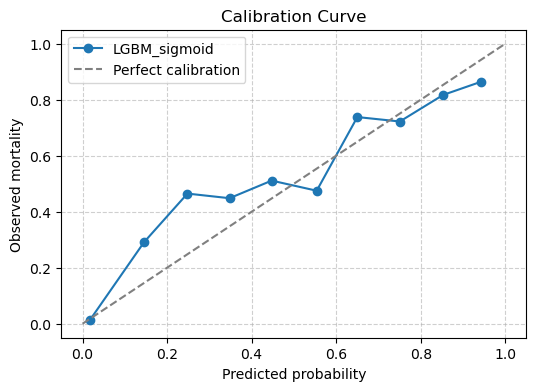

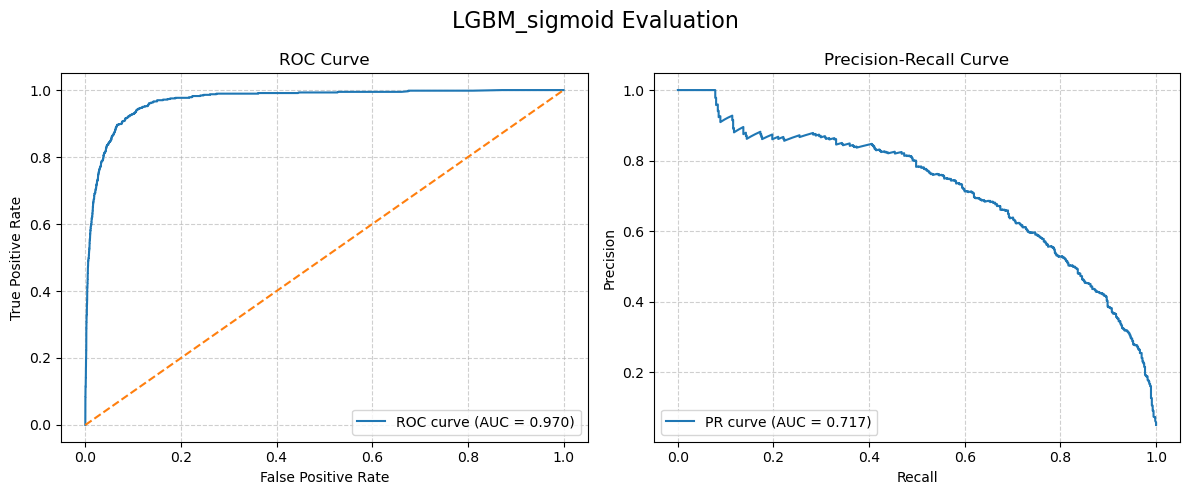


------ CatBoost ------

Fitting 5 folds for each of 2 candidates, totalling 10 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     10634
           1       0.61      0.70      0.65       562

    accuracy                           0.96     11196
   macro avg       0.80      0.84      0.82     11196
weighted avg       0.97      0.96      0.96     11196



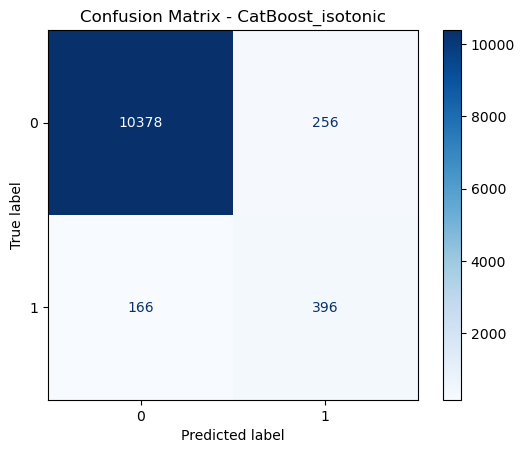

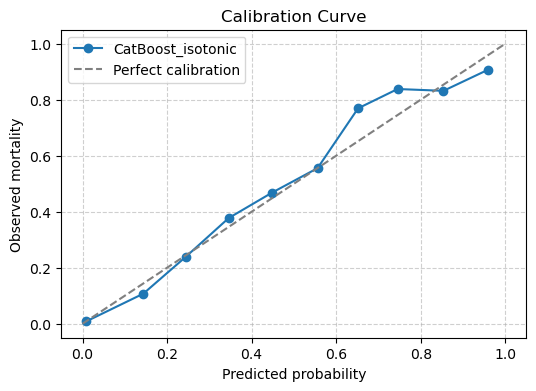

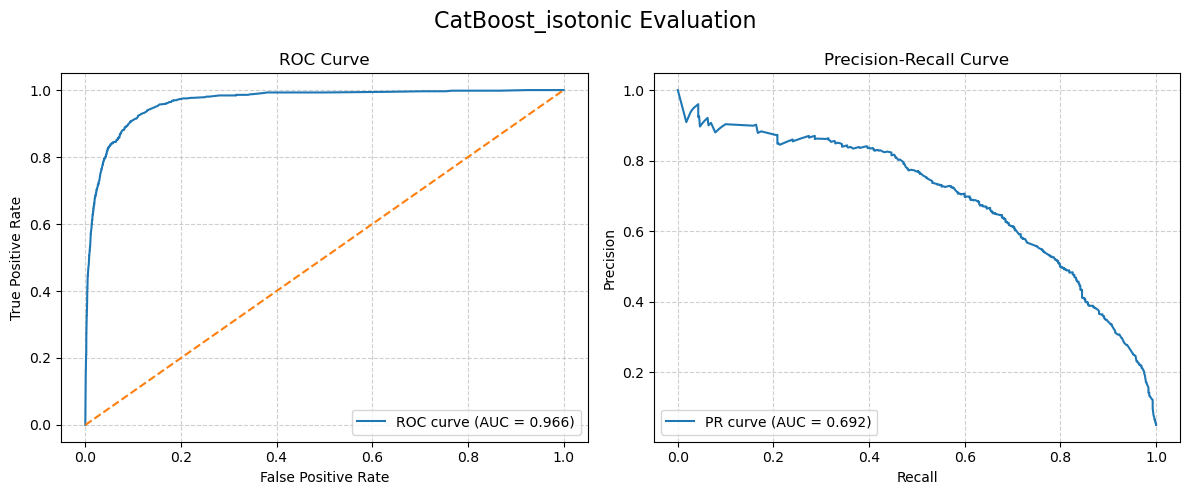


Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     10634
           1       0.60      0.71      0.65       562

    accuracy                           0.96     11196
   macro avg       0.79      0.84      0.81     11196
weighted avg       0.97      0.96      0.96     11196



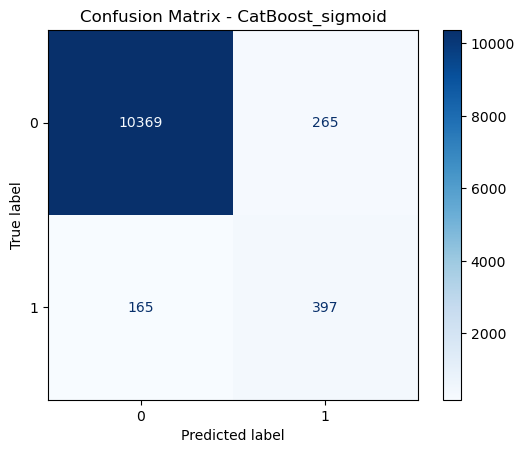

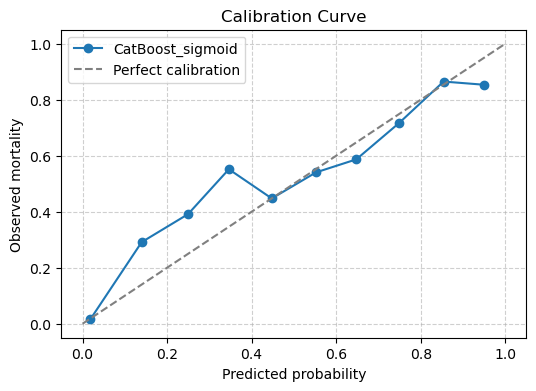

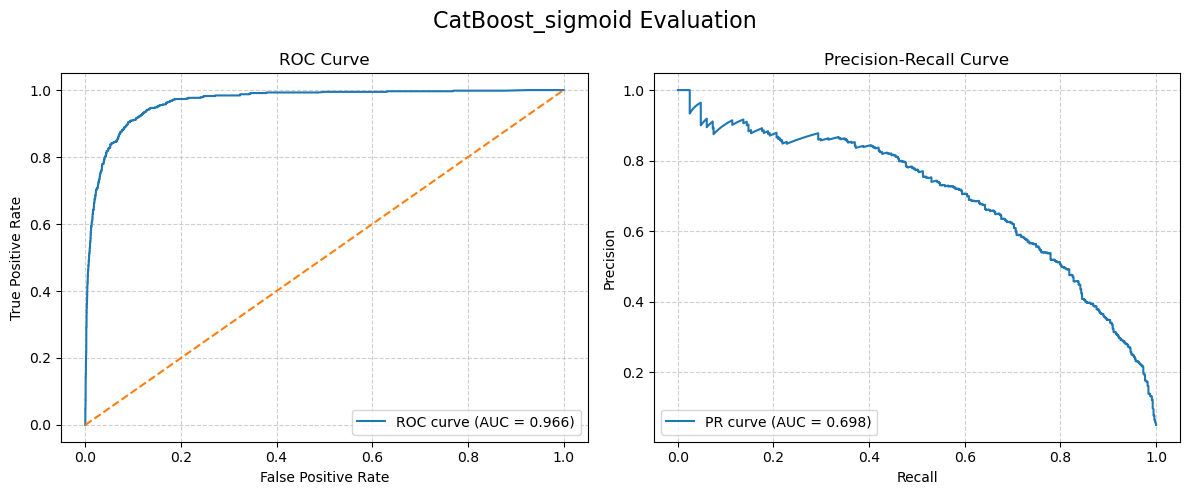

In [27]:
# Train and predict finalist models with calibration

target_recall = 0.7
results_calibration = []

for name, model in finalist_models.items():

    print(f"\n------ {name} ------\n")

    # Stratified Cross-Validation
    cv_pr_auc, cv_roc_auc = stratified_CV(model, X_train, y_train, n_splits=3)

    # Hyperparamater tuning
    param_grid = finalist_param_grids[name]
    best_score, best_params, best_model = hyperparameter_tune(model, param_grid, X_train, y_train, iters=50)
    
    calibrations = ['isotonic', 'sigmoid']

    for cal in calibrations:

        # Calibrate the model and train it
        calibrated_model = calibrate_model(best_model, X_train, y_train, cal)

        # Save model
        joblib.dump(calibrated_model, f"saved_models/calibrated/{name}_calibrated_{cal}.pkl")

        # Threshold tunning
        probs_val = calibrated_model.predict_proba(X_val)[:,1]
        threshold = select_threshold_for_recall(y_val, probs_val, target_recall)

        # Predictions
        probs_test = calibrated_model.predict_proba(X_test)[:,1]
        y_pred = (probs_test >= threshold).astype(int)    

        # Evaluate
        roc_auc, pr_auc, precision, recall, f1, brier, flag_rate = evaluate_model(y_test, probs_test, y_pred, f'{name}_{cal}')

        results_calibration.append({
            'Model': name,
            'Calibration': cal,
            'CV_PR_AUC': cv_pr_auc,
            'CV_ROC_AUC': cv_roc_auc,
            'BEST_CV_PR_AUC': best_score,
            'TEST_PR_AUC': pr_auc,
            'TEST_ROC_AUC': roc_auc,
            'Recall': recall,
            'Precision': precision,
            'F1': f1,
            'Brier': brier,
            'Threshold': threshold,
            'Flag_rate': flag_rate,
            'Best_Params': best_params
        })

        
        calibration_curve_plot(probs_test, y_test, f'{name}_{cal}')
        plot_pr_roc_auc(roc_auc, pr_auc, y_test, probs_test, f'{name}_{cal}')

df_results_calibration = pd.DataFrame(results_calibration)
df_results_calibration.to_csv('model_results/results_calibration.csv', index=False)

In [31]:
df_results_calibration

,Model,Calibration,CV_PR_AUC,CV_ROC_AUC,BEST_CV_PR_AUC,TEST_PR_AUC,TEST_ROC_AUC,Recall,Precision,F1,Brier,Threshold,Flag_rate,Best_Params
0,XGBoost,isotonic,0.685831,0.959741,0.694221,0.705817,0.968283,0.733096,0.618619,0.671010,0.023972,0.292134,0.059486,"{'subsample': 0.7, 'min_child_weight': 3, 'max..."
1,XGBoost,sigmoid,0.685831,0.959741,0.694221,0.707256,0.968288,0.733096,0.613095,0.667747,0.025533,0.117137,0.060021,"{'subsample': 0.7, 'min_child_weight': 3, 'max..."
2,LGBM,isotonic,0.686341,0.960747,0.692457,0.719961,0.969662,0.693950,0.635179,0.663265,0.023566,0.314340,0.054841,"{'subsample': 0.7, 'num_leaves': 31, 'n_estima..."
3,LGBM,sigmoid,0.686341,0.960747,0.692457,0.717034,0.970204,0.690391,0.652101,0.670700,0.025062,0.164993,0.053144,"{'subsample': 0.7, 'num_leaves': 31, 'n_estima..."
4,CatBoost,isotonic,0.691513,0.960450,0.682911,0.692376,0.965804,0.704626,0.607362,0.652389,0.024538,0.273373,0.058235,"{'learning_rate': 0.05, 'l2_leaf_reg': 3, 'ite..."
5,CatBoost,sigmoid,0.691513,0.960450,0.682911,0.697999,0.966152,0.706406,0.599698,0.648693,0.025915,0.108849,0.059128,"{'learning_rate': 0.05, 'l2_leaf_reg': 3, 'ite..."


## 5. Class Imbalance Handling Experiments

Several class imbalance handling strategies are evaluated using the isotonic-calibrated LightGBM model, as it achieved the best overall performance.  
Although previous experiments showed strong performance without additional balancing techniques, further analyses are conducted to determine if minority class detection can be improved.

The following approaches are evaluated:

1. Class weighting
2. SMOTE
3. SMOTETomek
4. SMOTEENN
5. Random undersampling


In [12]:
# Class Weighting
imb_ratio = (y.value_counts()[0] / y.value_counts()[1])

class_weighting_lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1,
    scale_pos_weight=imb_ratio
)

# SMOTE + LGBM
smote_pipeline = Pipeline([
    ('smote', SMOTE(
        sampling_strategy=0.3,
        random_state=42
    )),
    ('model', lgbm_model)
])

# SMOTETomek + LGBM
smotetomek_pipeline = Pipeline([
    ('smotetomek', SMOTETomek(
        sampling_strategy=0.3,
        random_state=42
    )),
    ('model', lgbm_model)
])

# SMOTEENN + LGBM
smoteenn_pipeline = Pipeline([
    ('smoteenn', SMOTEENN(
        sampling_strategy=0.3,
        random_state=42
    )),
    ('model', lgbm_model)
])

# Random UnderSampling + LGBM
undersample_pipeline = Pipeline([
    ('undersample', RandomUnderSampler(
        sampling_strategy = 0.3,
        random_state=42
    )),
    ('model', lgbm_model)
])

In [13]:
imbalance_models = {
    'Class_Weighting' : class_weighting_lgbm,
    'SMOTE': smote_pipeline,
    'SMOTETomek' : smotetomek_pipeline,
    'SMOTEENN' : smoteenn_pipeline,
    'Under_Sampling': undersample_pipeline
}

param_grid_lgbm_pipeline = {
    'model__n_estimators': [200, 400],
    'model__learning_rate': [0.01, 0.05],
    'model__num_leaves': [31, 50],
    'model__max_depth': [-1, 5],
    'model__subsample': [0.7, 0.8]
}


------ Class_Weighting ------

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     10634
           1       0.60      0.72      0.66       562

    accuracy                           0.96     11196
   macro avg       0.79      0.85      0.82     11196
weighted avg       0.97      0.96      0.96     11196



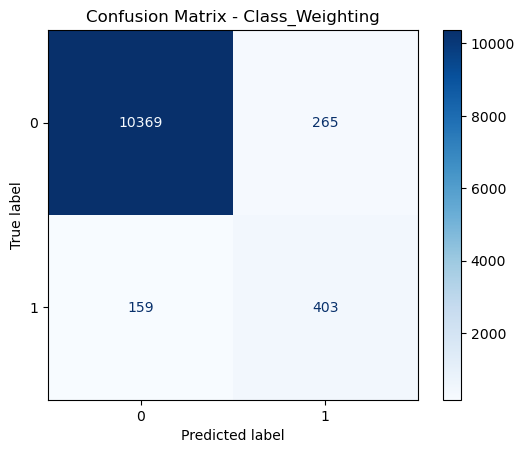

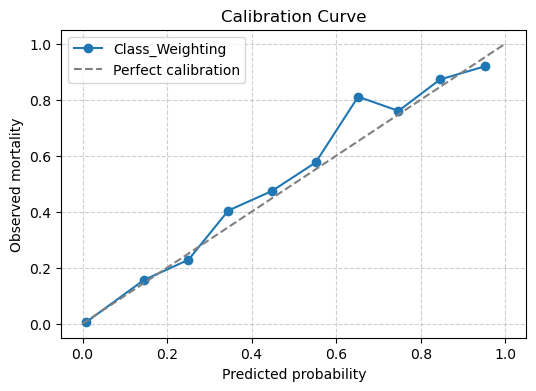

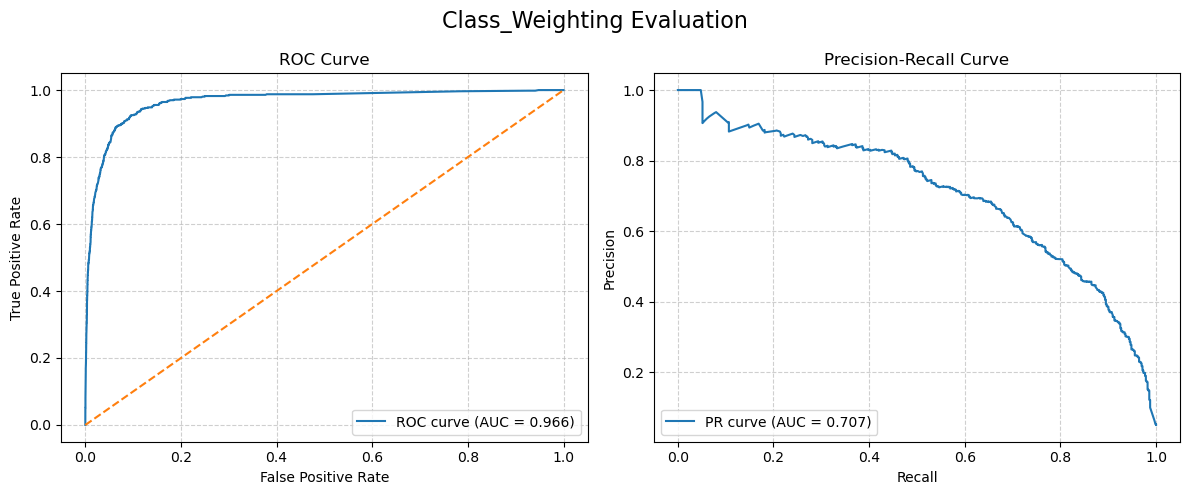


------ SMOTE ------

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98     10634
           1       0.55      0.72      0.63       562

    accuracy                           0.96     11196
   macro avg       0.77      0.84      0.80     11196
weighted avg       0.96      0.96      0.96     11196



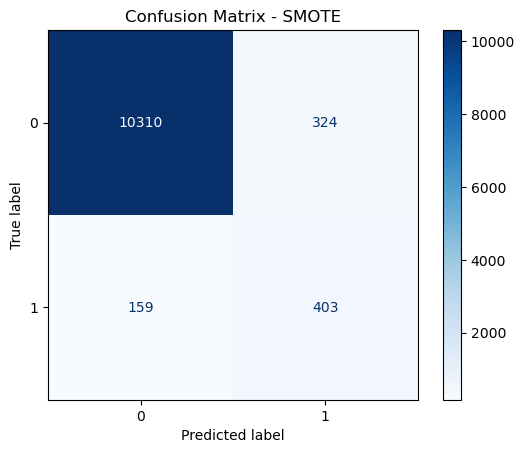

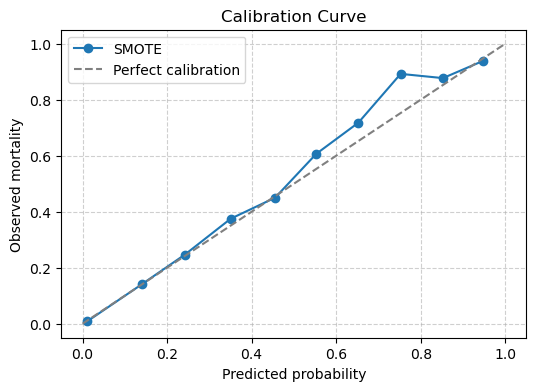

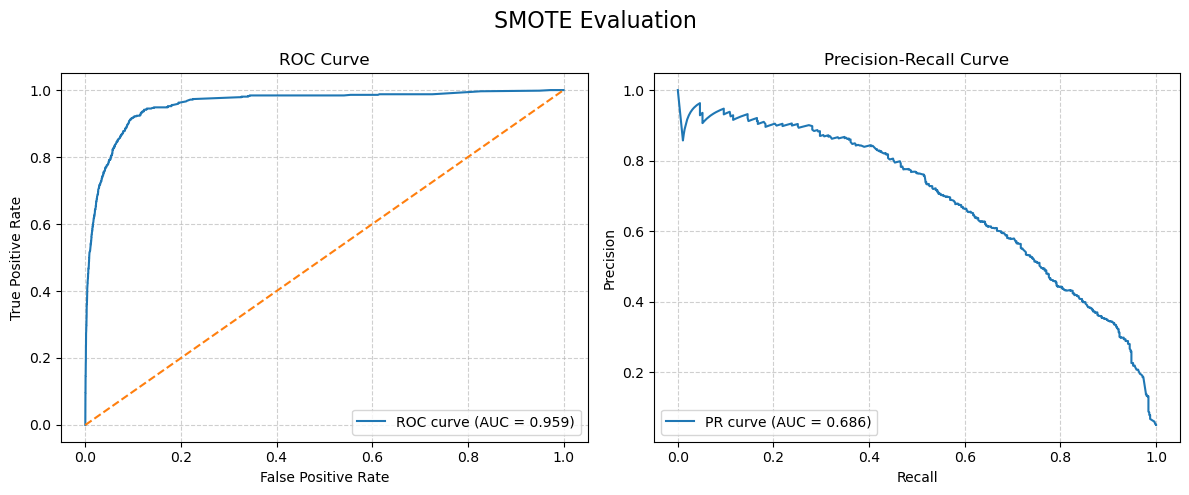


------ SMOTETomek ------

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98     10634
           1       0.56      0.71      0.63       562

    accuracy                           0.96     11196
   macro avg       0.77      0.84      0.80     11196
weighted avg       0.96      0.96      0.96     11196



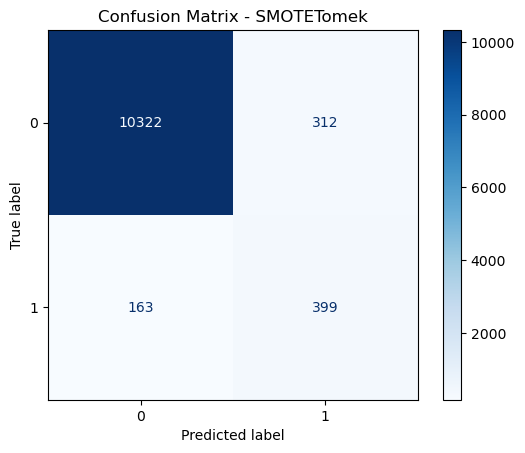

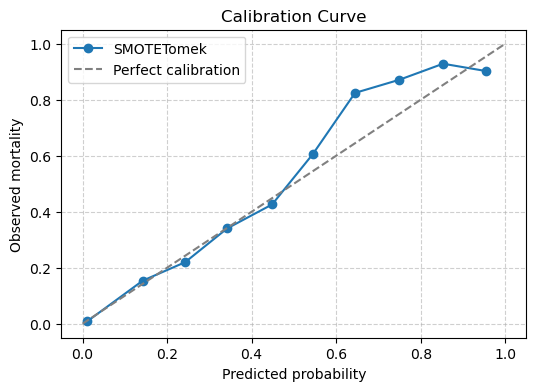

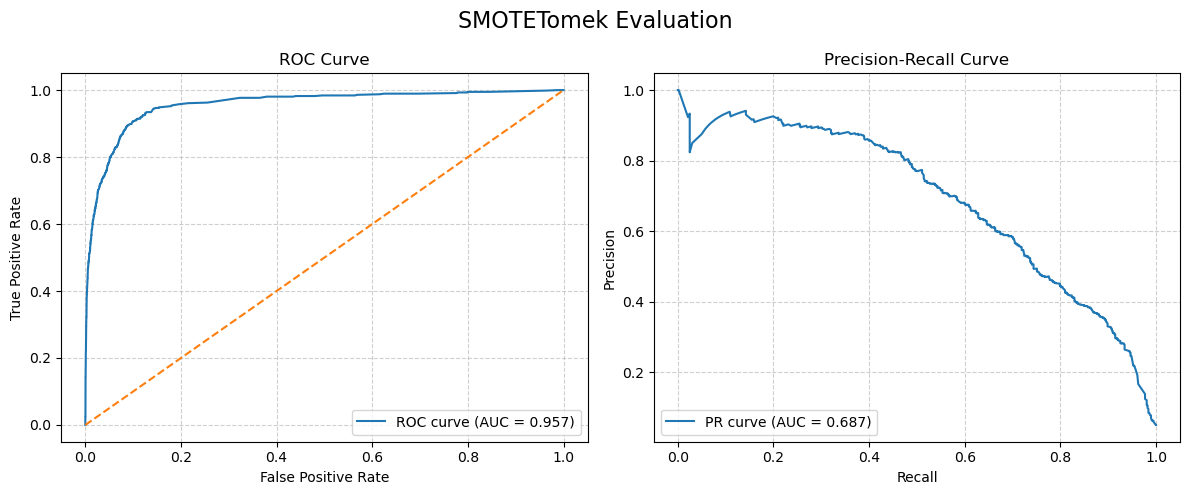


------ SMOTEENN ------

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98     10634
           1       0.55      0.73      0.63       562

    accuracy                           0.96     11196
   macro avg       0.77      0.85      0.80     11196
weighted avg       0.96      0.96      0.96     11196



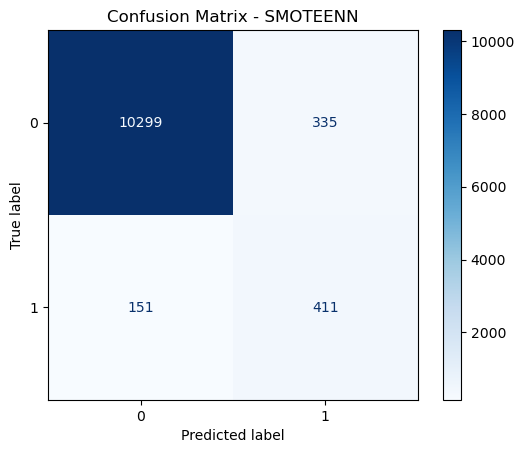

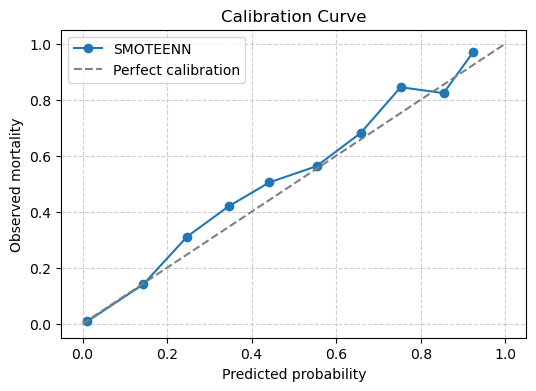

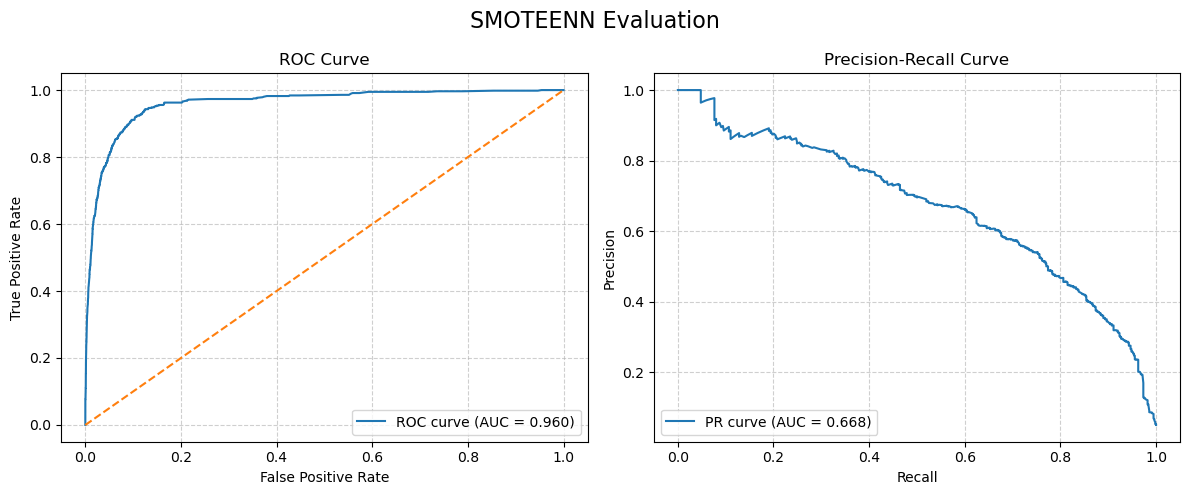


------ Under_Sampling ------

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     10634
           1       0.62      0.70      0.66       562

    accuracy                           0.96     11196
   macro avg       0.80      0.84      0.82     11196
weighted avg       0.97      0.96      0.96     11196



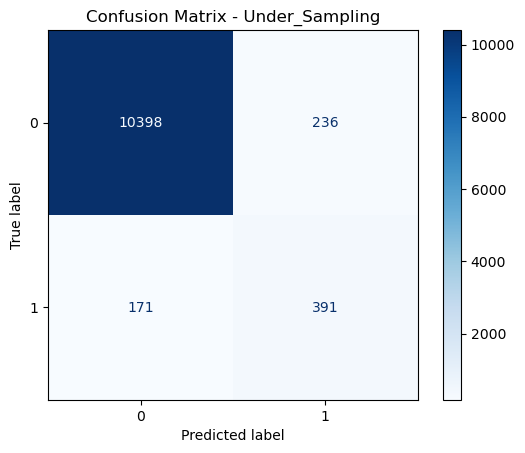

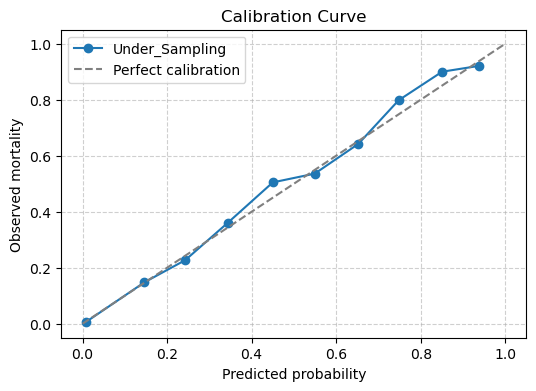

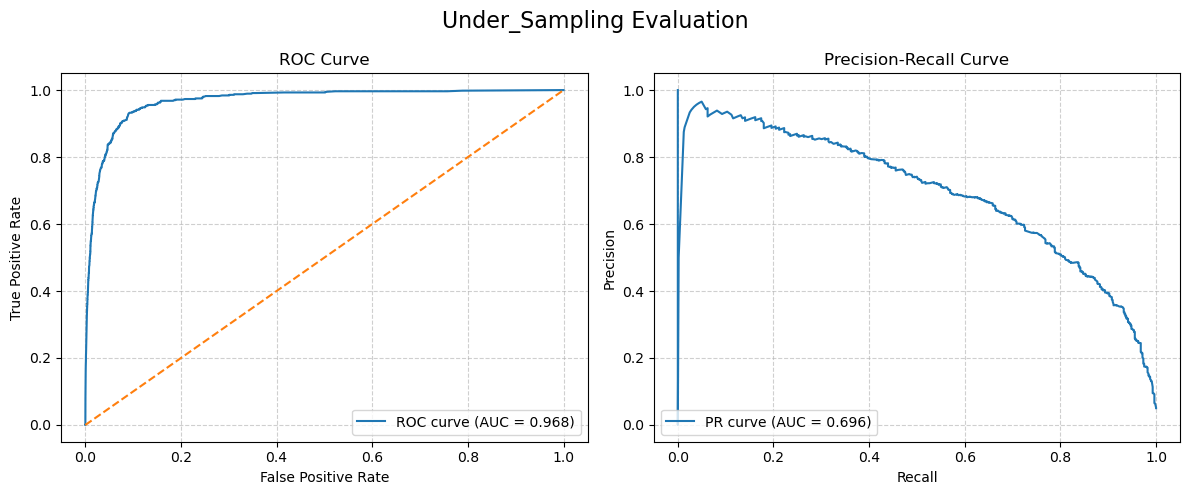

In [15]:
# Train and predict finalist models with class imbalance handling

target_recall = 0.7
results_imbalance = []

for name, model in imbalance_models.items():

    print(f"\n------ {name} ------\n")

    # Stratified Cross-Validation
    cv_pr_auc, cv_roc_auc = stratified_CV(model, X_train, y_train, n_splits=3)

    # Hyperparamater tuning
    best_score, best_params, best_model = hyperparameter_tune(model, param_grid_lgbm_pipeline, X_train, y_train, 20)

    # Calibrate the model and train it
    calibrated_model = calibrate_model(best_model, X_train, y_train, 'isotonic')

    # Save model
    joblib.dump(calibrated_model, f"saved_models/imbalance/{name}_imbalance.pkl")

    # Threshold tunning
    probs_val = calibrated_model.predict_proba(X_val)[:,1]
    threshold = select_threshold_for_recall(y_val, probs_val, target_recall)

    # Predictions
    probs_test = calibrated_model.predict_proba(X_test)[:,1]
    y_pred = (probs_test >= threshold).astype(int)    

    # Evaluate
    roc_auc, pr_auc, precision, recall, f1, brier, flag_rate = evaluate_model(y_test, probs_test, y_pred, name)

    results_imbalance.append({
        'Model': name,
        'CV_PR_AUC': cv_pr_auc,
        'CV_ROC_AUC': cv_roc_auc,
        'BEST_CV_PR_AUC': best_score,
        'TEST_PR_AUC': pr_auc,
        'TEST_ROC_AUC': roc_auc,
        'Recall': recall,
        'Precision': precision,
        'F1': f1,
        'Brier': brier,
        'Threshold': threshold,
        'Flag_rate': flag_rate,
        'Best_Params': best_params
    })

    
    calibration_curve_plot(probs_test, y_test, name)
    plot_pr_roc_auc(y_test, probs_test, name)

df_results_imbalance = pd.DataFrame(results_imbalance)
df_results_imbalance.to_csv('model_results/results_imbalance.csv', index=False)

In [32]:
df_results_imbalance

,Model,CV_PR_AUC,CV_ROC_AUC,BEST_CV_PR_AUC,TEST_PR_AUC,TEST_ROC_AUC,Recall,Precision,F1,Brier,Threshold,Flag_rate,Best_Params
0,Class_Weighting,0.666401,0.954123,0.677185,0.717851,0.963872,0.722420,0.637363,0.677231,0.023505,0.284191,0.056895,"{'model__subsample': 0.8, 'model__num_leaves':..."
1,SMOTE,0.630025,0.950424,0.639982,0.687104,0.957733,0.759786,0.546036,0.635417,0.024938,0.204365,0.069846,"{'model__subsample': 0.8, 'model__num_leaves':..."
2,SMOTETomek,0.627615,0.949576,0.641842,0.694103,0.956778,0.734875,0.581690,0.649371,0.024774,0.236434,0.063416,"{'model__subsample': 0.8, 'model__num_leaves':..."
3,SMOTEENN,0.632274,0.949794,0.638174,0.656843,0.961698,0.743772,0.542857,0.627628,0.026112,0.216092,0.068775,"{'model__subsample': 0.8, 'model__num_leaves':..."
4,Under_Sampling,0.658238,0.960041,0.666409,0.717390,0.971564,0.724199,0.609281,0.661789,0.023763,0.292982,0.059664,"{'model__subsample': 0.8, 'model__num_leaves':..."


## 6. Final Model Optimization (LightGBM)

An additional optimization stage is performed on the selected LightGBM model, without using any class-imbalance handling technique as no improvement was acheived.  
Expanded hyperparameter tuning and alternative threshold configurations are explored to evaluate different trade-offs between sensitivity, precision, and the proportion of patients identified as high risk.

In [20]:
# Define the base model
lgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1
)

# Define the paramater grid to optimize
param_grid_lgbm_pipeline = {
    'scale_pos_weight': [1, 2, 4, 6, 8, 10, 12, 16],    # positive class weights
    'n_estimators': [200, 400, 600],                    # pair with learning rate
    'learning_rate': [0.01, 0.03, 0.05],                # lower improves generalization but rquire more trees
    'num_leaves': [15, 31, 50, 70],                     # model complexity: higher captures nonlinear interactions but overfits more
    'max_depth': [-1, 3, 5, 7],                         # limits tree growth
    'subsample': [0.6, 0.7, 0.8, 1.0],                  # regularization through row samling
    'min_child_samples': [20, 50, 100],                 # number of samples per leaf: higher smoother model, less overfiting, better calibration
    'colsample_bytree': [0.6, 0.8, 1.0]                 # regularization thorugh feature sampling
}

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[600]	valid_0's average_precision: 0.724281	valid_0's binary_logloss: 0.0827943


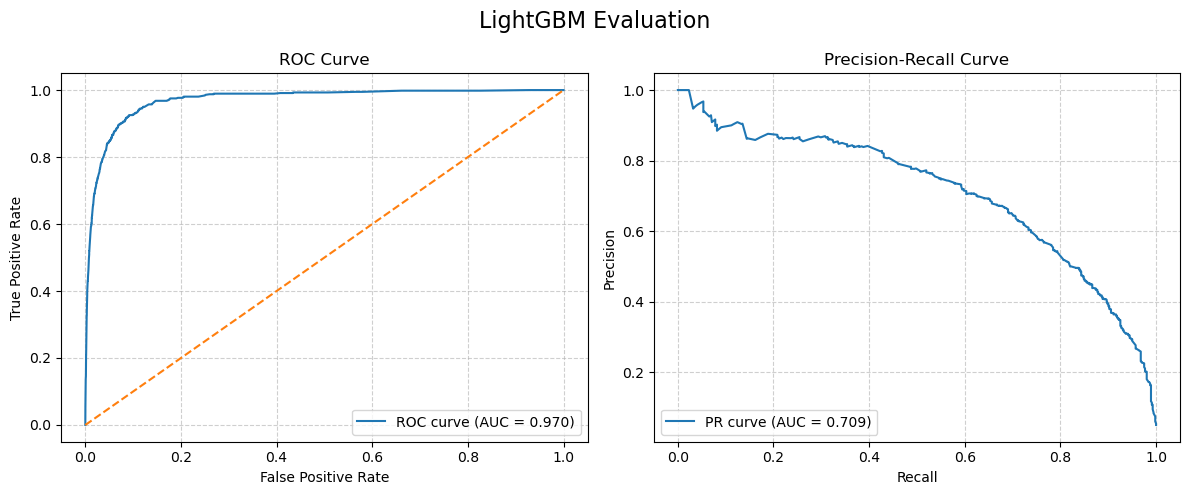

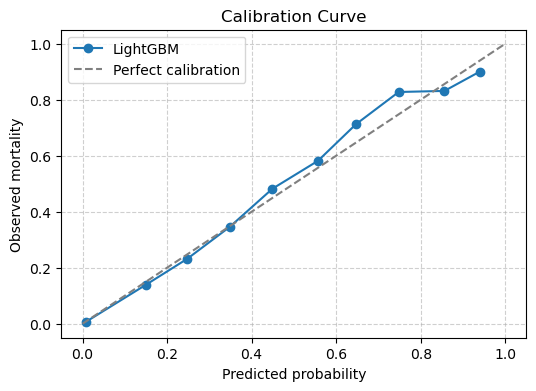

In [21]:
# Train and predict the best final model

# Stratified Cross-Validation
cv_pr_auc, cv_roc_auc = stratified_CV(lgbm_model, X_train, y_train, n_splits=3)

# Hyperparamater tuning
best_score, best_params, best_model = hyperparameter_tune(lgbm_model, param_grid_lgbm_pipeline, X_train, y_train, iters=20)

# Train best model with early stopping
best_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[early_stopping(stopping_rounds=50)]
)

# Calibrate the models and train it
best_model_cal = calibrate_model(best_model, X_train, y_train, 'isotonic')

# Save models
joblib.dump(best_model_cal, f"saved_models/best_model/best_lgbm_iso.pkl")

# Predictions
probs_test = best_model_cal.predict_proba(X_test)[:,1]
probs_val = best_model_cal.predict_proba(X_val)[:,1]

plot_pr_roc_auc(y_test, probs_test, 'LightGBM')
calibration_curve_plot(probs_test, y_test, 'LightGBM')


------ Target recall: 0.65 ------


Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     10634
           1       0.68      0.66      0.67       562

    accuracy                           0.97     11196
   macro avg       0.83      0.82      0.83     11196
weighted avg       0.97      0.97      0.97     11196



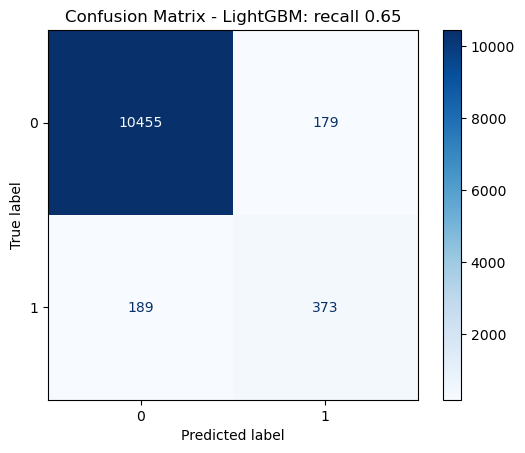


------ Target recall: 0.7 ------


Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     10634
           1       0.64      0.71      0.67       562

    accuracy                           0.97     11196
   macro avg       0.81      0.84      0.83     11196
weighted avg       0.97      0.97      0.97     11196



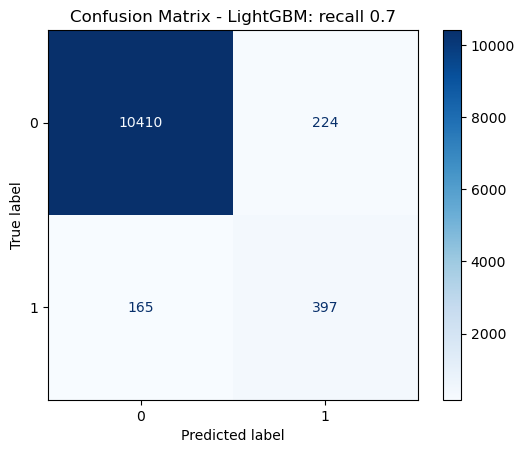


------ Target recall: 0.75 ------


Classification report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98     10634
           1       0.58      0.75      0.66       562

    accuracy                           0.96     11196
   macro avg       0.78      0.86      0.82     11196
weighted avg       0.97      0.96      0.96     11196



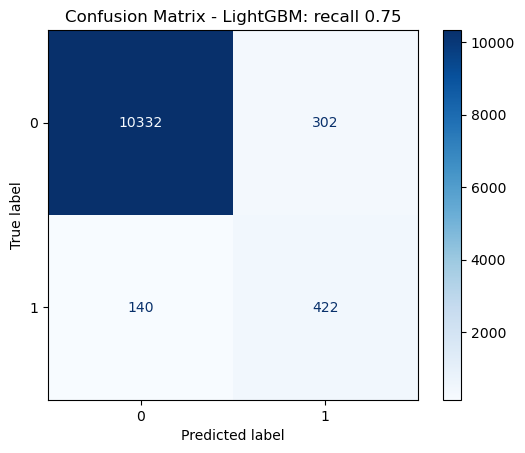

In [25]:
target_recalls = [0.65, 0.70, 0.75]
results = []
predictions_final_model = {}

for r in target_recalls:

    print(f"\n------ Target recall: {r} ------\n")

    # Threshold tunning
    threshold = select_threshold_for_recall(y_val, probs_val, r)

    # Predictions
    y_pred = (probs_test >= threshold).astype(int)    

    # Evaluate
    roc_auc, pr_auc, precision, recall, f1, brier, flag_rate = evaluate_model(y_test, probs_test, y_pred, f'LightGBM: recall {r}')

    results.append({
        'Target recall': r,
        'CV_PR_AUC': cv_pr_auc,
        'CV_ROC_AUC': cv_roc_auc,
        'BEST_CV_PR_AUC': best_score,
        'TEST_PR_AUC': pr_auc,
        'TEST_ROC_AUC': roc_auc,
        'Recall': recall,
        'Precision': precision,
        'F1': f1,
        'Brier': brier,
        'Threshold': threshold,
        'Flag_rate': flag_rate,
        'Best_Params': best_params
    })

    # Save predictions
    predictions_final_model[r] = pd.DataFrame({
        'true_label': y_test.squeeze(),
        'predicted_probability': probs_test,
        'predicted_label': y_pred,
        'MACA': chronic_labels.loc[y_test.index, 'MACA'].astype(int),
        'PCC': chronic_labels.loc[y_test.index, 'PCC'].astype(int),
        'sex': data.loc[y_test.index, 'sexe']
    })


df_results_final = pd.DataFrame(results)
df_results_final.to_csv(f'model_results/best_LGBM.csv', index=False)

In [26]:
df_results_final

,Target recall,CV_PR_AUC,CV_ROC_AUC,BEST_CV_PR_AUC,TEST_PR_AUC,TEST_ROC_AUC,Recall,Precision,F1,Brier,Threshold,Flag_rate,Best_Params
0,0.65,0.686341,0.960747,0.692725,0.709009,0.970062,0.663701,0.675725,0.669659,0.023725,0.376614,0.049303,"{'subsample': 0.6, 'scale_pos_weight': 1, 'num..."
1,0.70,0.686341,0.960747,0.692725,0.709009,0.970062,0.706406,0.639291,0.671175,0.023725,0.323544,0.055466,"{'subsample': 0.6, 'scale_pos_weight': 1, 'num..."
2,0.75,0.686341,0.960747,0.692725,0.709009,0.970062,0.750890,0.582873,0.656299,0.023725,0.256673,0.064666,"{'subsample': 0.6, 'scale_pos_weight': 1, 'num..."


In [28]:
predictions_final_model[0.70].to_csv('model_results/best_LGBM_predictions.csv', index=False)

## 7. Relationship Between Predicted Mortality Risk and Chronicity Labels

Two complementary analyses are performed to investigate the relationship between predicted mortality risk and chronicity labels. 
1. Patients are stratified according to their predicted risk to examine mortality and chronicity gradients. 
2. Chronicity prevalence is analyzed across prediction groups to identify clinically meaningful patterns beyond binary classification performance.

### 7.1 Risk Stratification Across Predicted Risk Groups

In [2]:
predictions = pd.read_csv('model_results/best_LGBM_predictions.csv')
predictions['predicted_probability'] = (predictions['predicted_probability'] * 100).round(2)

# Add non-chronic label
predictions['non_chronic'] = np.where(
    (predictions['PCC'] == 0) & (predictions['MACA'] == 0), 1, 0
)

predictions.head()

,true_label,predicted_probability,predicted_label,MACA,PCC,sex,non_chronic
0,0,0.04,0,0,0,1,1
1,0,1.52,0,0,0,0,1
2,0,0.08,0,0,0,1,1
3,0,0.18,0,0,0,0,1
4,0,0.18,0,0,0,0,1


In [3]:
# Create risk groups
predictions['risk_group'] = pd.qcut(
    predictions['predicted_probability'],
    q=10,
    labels=False,
    duplicates='drop'   # remove duplicated boundaries across deciles - one decile disappears, 9 groups
)

# Mortality by group
decile_summary = predictions.groupby('risk_group').agg(
    mortality_risk=('predicted_probability', 'mean'),
    observed_mortality=('true_label', 'mean'),
    MACA_prevalence=('MACA', 'mean'),
    PCC_prevalence=('PCC', 'mean'),
    non_chronic_prevalence=('non_chronic', 'mean'),
    n_patients=('true_label', 'count')
)

cols_to_pct = [
    'observed_mortality',
    'MACA_prevalence',
    'PCC_prevalence',
    'non_chronic_prevalence'
]

decile_summary['mortality_risk'] = decile_summary['mortality_risk'] .round(2)
decile_summary[cols_to_pct] = (decile_summary[cols_to_pct] * 100).round(2)

decile_summary.reset_index(inplace=True)
display(decile_summary)

,risk_group,mortality_risk,observed_mortality,MACA_prevalence,PCC_prevalence,non_chronic_prevalence,n_patients
0,0,0.02,0.05,0.00,0.27,99.73,1859
1,1,0.08,0.00,0.00,0.29,99.71,1740
2,2,0.12,0.23,0.00,1.01,98.99,887
3,3,0.19,0.08,0.08,1.65,98.27,1330
4,4,0.35,0.22,0.11,6.56,93.33,914
5,5,0.75,0.09,0.18,14.35,85.47,1115
6,6,1.34,0.98,0.89,18.07,81.04,1118
7,7,4.89,5.08,3.74,32.17,64.08,1122
8,8,43.46,43.83,20.70,54.82,24.48,1111


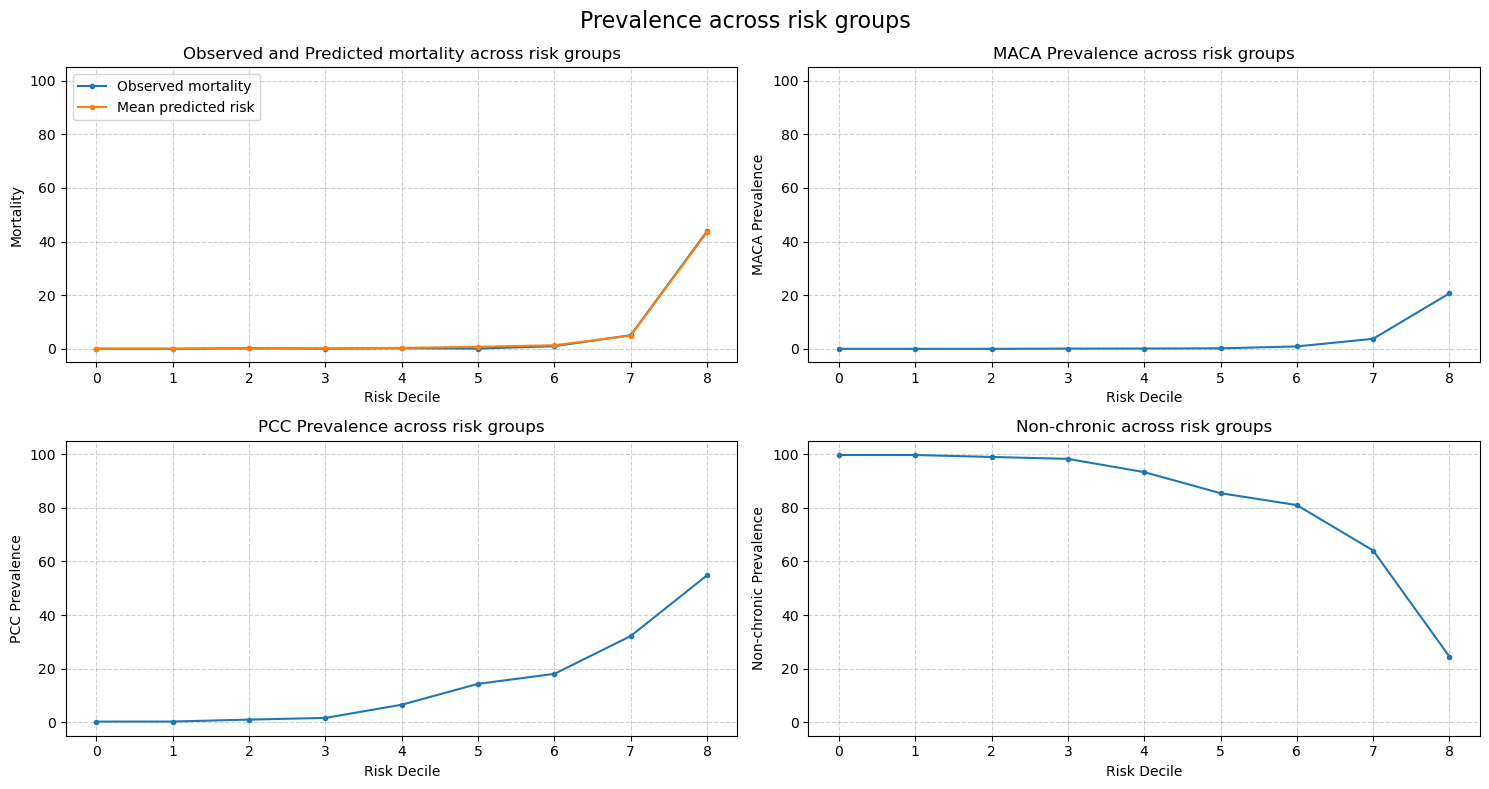

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Observed mortality across groups
axes[0,0].plot(decile_summary['risk_group'], decile_summary['observed_mortality'], label=f'Observed mortality', marker='.')
axes[0,0].plot(decile_summary['risk_group'], decile_summary['mortality_risk'], label=f'Mean predicted risk', marker='.')
axes[0,0].set_xlabel('Risk Decile')
axes[0,0].set_ylabel('Mortality')
axes[0,0].set_title('Observed and Predicted mortality across risk groups')
axes[0,0].legend(loc='upper left')
axes[0,0].set_ylim(bottom=-5, top=105)
axes[0,0].grid(True, linestyle='--', alpha=0.6)

# MACA Prevalence across groups
axes[0,1].plot(decile_summary['risk_group'], decile_summary['MACA_prevalence'], marker='.')
axes[0,1].set_xlabel('Risk Decile')
axes[0,1].set_ylabel('MACA Prevalence')
axes[0,1].set_title('MACA Prevalence across risk groups')
axes[0,1].set_ylim(bottom=-5, top=105)
axes[0,1].grid(True, linestyle='--', alpha=0.6)

# PCC Prevalence across groups
axes[1,0].plot(decile_summary['risk_group'], decile_summary['PCC_prevalence'], marker='.')
axes[1,0].set_xlabel('Risk Decile')
axes[1,0].set_ylabel('PCC Prevalence')
axes[1,0].set_title('PCC Prevalence across risk groups')
axes[1,0].set_ylim(bottom=-5, top=105)
axes[1,0].grid(True, linestyle='--', alpha=0.6)

# PCC Prevalence across groups
axes[1,1].plot(decile_summary['risk_group'], decile_summary['non_chronic_prevalence'], marker='.')
axes[1,1].set_xlabel('Risk Decile')
axes[1,1].set_ylabel('Non-chronic Prevalence')
axes[1,1].set_title('Non-chronic across risk groups')
axes[1,1].set_ylim(bottom=-5, top=105)
axes[1,1].grid(True, linestyle='--', alpha=0.6)

fig.suptitle('Prevalence across risk groups', size=16)
plt.tight_layout()
plt.show()

**Risk groups**: due to duplicated probability values in low-risk patients, quantile binning yielded 9 effective groups instead of 10.
- The objective was to split predicted probabilities into 10 equally sized groups.
- Predictions contain many repeated values (small probabilities), which is very common in imbalanced clinical datasets.
- Some quantile boundaries are identical, so the duplicated edges are removed in order to create unique boundaries.
- We ended up with 9 groups instead of 10 (deciles).

### 7.2 Chronicity Distribution Across Prediction Groups

In [4]:
# Add confusion maytrix info
predictions['prediction_group'] = np.where(
    (predictions['true_label'] == 0) & (predictions['predicted_label'] == 0), 'TN', 
    np.where(
         (predictions['true_label'] == 0) & (predictions['predicted_label'] == 1), 'FP',
         np.where(
             (predictions['true_label'] == 1) & (predictions['predicted_label'] == 0), 'FN', 'TP'
         )
    ))

# Add chronicity column
predictions['chronicity'] = np.where(
    (predictions['PCC'] == 1) , 'PCC',
    np.where(
         (predictions['MACA'] == 1), 'MACA', 'Non-chronic'
    ))

predictions.head()

,true_label,predicted_probability,predicted_label,MACA,PCC,sex,non_chronic,risk_group,prediction_group,chronicity
0,0,0.04,0,0,0,1,1,0,TN,Non-chronic
1,0,1.52,0,0,0,0,1,6,TN,Non-chronic
2,0,0.08,0,0,0,1,1,1,TN,Non-chronic
3,0,0.18,0,0,0,0,1,3,TN,Non-chronic
4,0,0.18,0,0,0,0,1,3,TN,Non-chronic


In [8]:
group_summary = predictions.groupby('prediction_group').agg(
    mortality_risk=('predicted_probability', 'mean'),
    MACA_prevalence=('MACA', 'mean'),
    PCC_prevalence=('PCC', 'mean'),
    non_chronic_prevalence=('non_chronic', 'mean'),
    n_patients=('true_label', 'size')
)

cols_to_pct = [
    'mortality_risk',
    'MACA_prevalence',
    'PCC_prevalence',
    'non_chronic_prevalence'
]

group_summary['mortality_risk'] = group_summary['mortality_risk'].round(2)
group_summary[cols_to_pct[1:]] = (group_summary[cols_to_pct[1:]] * 100).round(2)

group_summary = group_summary.reset_index()
display(group_summary)

,prediction_group,mortality_risk,MACA_prevalence,PCC_prevalence,non_chronic_prevalence,n_patients
0,FN,14.01,24.85,47.88,27.27,165
1,FP,51.92,15.18,64.73,20.09,224
2,TN,1.55,0.75,9.83,89.42,10410
3,TP,67.78,33.50,46.85,19.65,397


<Figure size 1000x600 with 0 Axes>

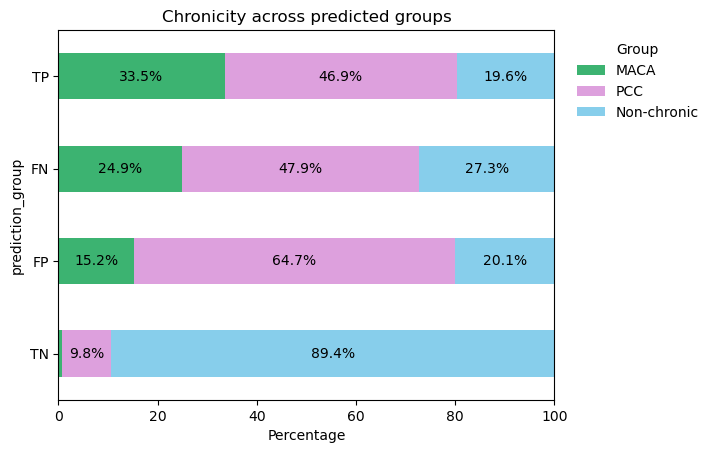

In [9]:
plot_df = group_summary[['prediction_group', 'MACA_prevalence', 'PCC_prevalence', 'non_chronic_prevalence']]
plot_df.set_index('prediction_group', inplace=True)
plot_df = plot_df.loc[['TN', 'FP', 'FN', 'TP']]

plt.figure(figsize=(10,6))

ax= plot_df.plot(kind='barh', stacked=True, color=['mediumseagreen', 'plum', 'skyblue'])

plt.title('Chronicity across predicted groups')
plt.xlabel('Percentage')
plt.xlim(0,100)
plt.xticks(rotation=0)
plt.legend(['MACA', 'PCC', 'Non-chronic'], title='Group', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

for c in ax.containers:
    labels = [f'{v:.1f}%' if v >= 5 else '' for v in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)

plt.show()

## 8. Model Explainability

SHAP values are computed to identify the variables that contribute most to mortality risk estimation.  
In addition, model performance is evaluated separately across sexes to assess the consistency of predictions between demographic groups.

### 8.1 Feature Importance

In [14]:
# SHAP
model = joblib.load('saved_models/best_model/best_lgbm_iso.pkl')
base_model = model.calibrated_classifiers_[0].estimator
explainer = shap.TreeExplainer(base_model)
shap_values = explainer.shap_values(X_test)

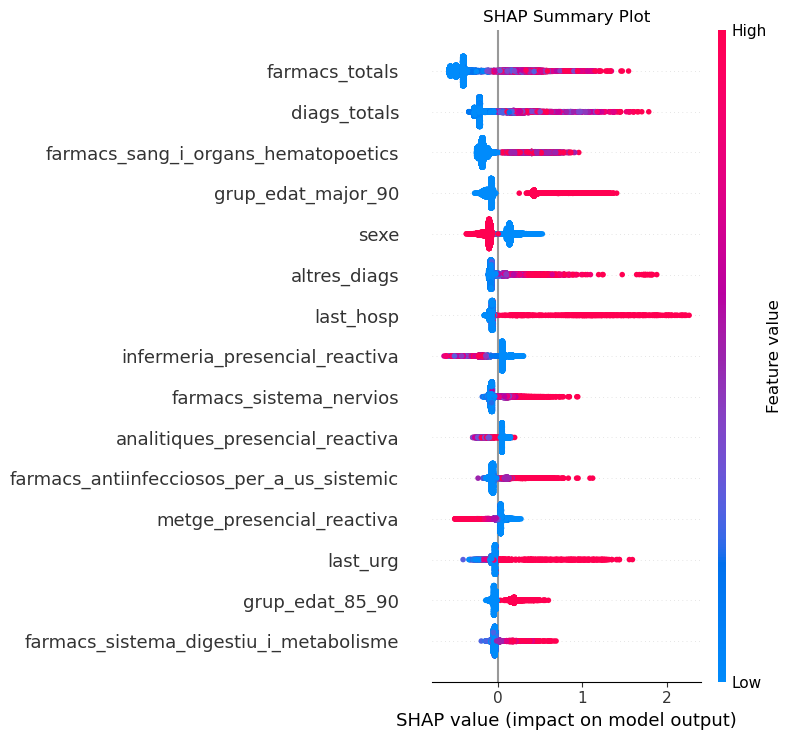

In [16]:
plt.figure(figsize=(6, 4))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

### 8.2 Check possible sex bias

In [50]:
predictions['sex_label'] = predictions['sex'].map({0:'Male', 1:'Female'})

# Mortality prevalence by sex
print(f"Mortality prevalence by sex in the full cohort: \n {data.groupby('sexe')['situacio'].agg('mean')*100}")
print(f"\nMortality prevalence by sex in test set: \n {predictions.groupby(['sex_label'])['true_label'].agg('mean')*100}")

# Mortality prediction by sex
print(f"\nMortality prediction by sex: \n {predictions.groupby(['sex_label', 'true_label'])['predicted_probability'].agg('mean')}")

Mortality prevalence by sex in the full cohort: 
 sexe
0    5.839010
1    4.427626
Name: situacio, dtype: float64

Mortality prevalence by sex in test set: 
 sex_label
Female    4.709311
Male      5.452213
Name: true_label, dtype: float64

Mortality prediction by sex: 
 sex_label  true_label
Female     0              2.625953
           1             51.178143
Male       0              2.584584
           1             52.977686
Name: predicted_probability, dtype: float64



------ Sex: Male ------


Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      4422
           1       0.69      0.72      0.70       255

    accuracy                           0.97      4677
   macro avg       0.84      0.85      0.84      4677
weighted avg       0.97      0.97      0.97      4677



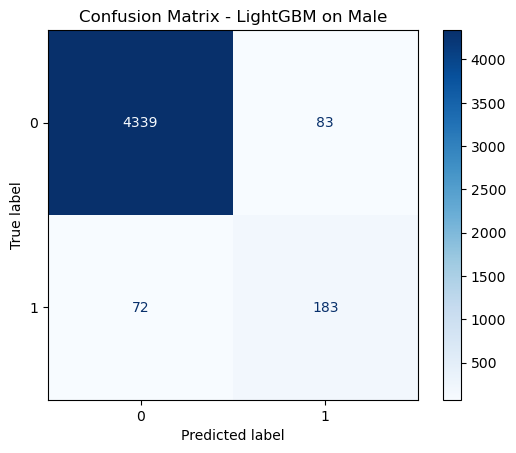

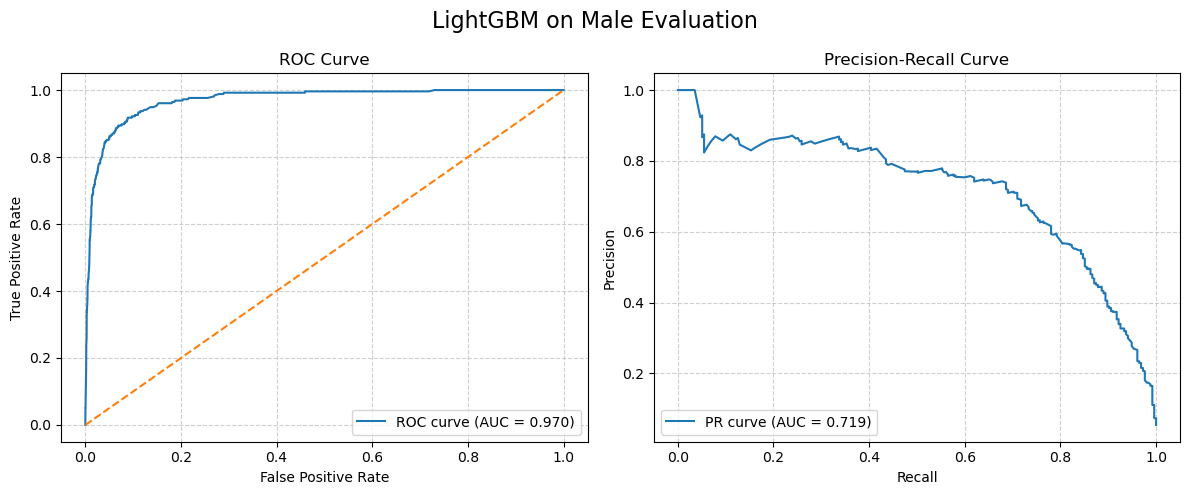

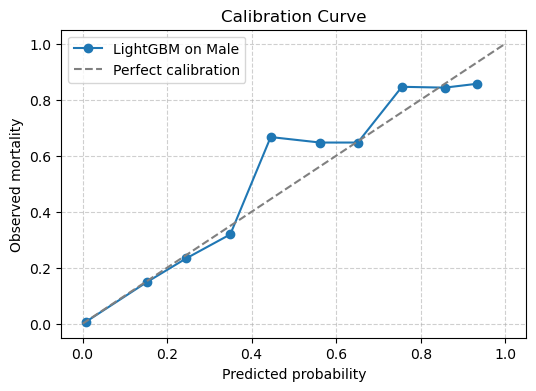


------ Sex: Female ------


Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      6212
           1       0.60      0.70      0.65       307

    accuracy                           0.96      6519
   macro avg       0.79      0.84      0.81      6519
weighted avg       0.97      0.96      0.97      6519



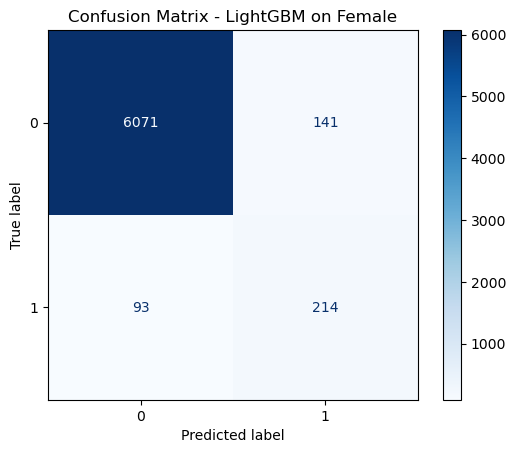

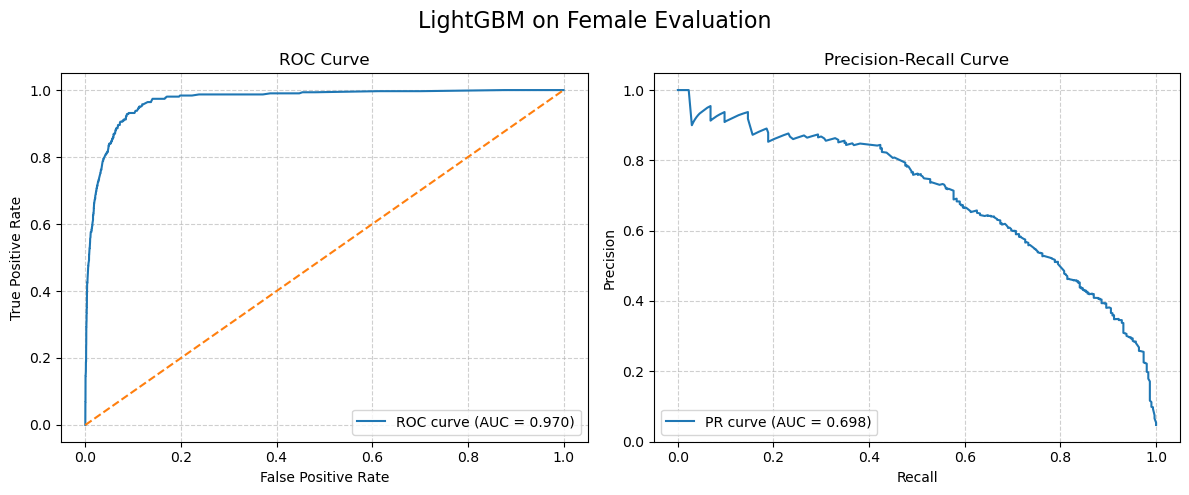

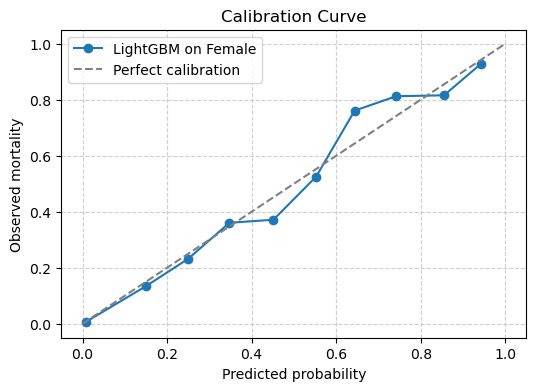

In [31]:
# Model performance by sex
results_sex = []

for sex in ['Male', 'Female']:

    subset = predictions[predictions['sex_label'] == sex]
    print(f"\n------ Sex: {sex} ------\n")
    roc_auc, pr_auc, precision, recall, f1, brier, flag_rate = evaluate_model(subset['true_label'], subset['predicted_probability']/100, subset['predicted_label'], f'LightGBM on {sex}')
    plot_pr_roc_auc(subset['true_label'], subset['predicted_probability'], f'LightGBM on {sex}')
    calibration_curve_plot(subset['predicted_probability']/100, subset['true_label'], f'LightGBM on {sex}')
    results_sex.append({
        'SEX': sex,
        'TEST_PR_AUC': pr_auc,
        'TEST_ROC_AUC': roc_auc,
        'Recall': recall,
        'Precision': precision,
        'F1': f1,
        'Brier': brier,
        'Flag_rate': flag_rate,
    })

df_results_sex = pd.DataFrame(results_sex)

In [ ]:
# Compare error rate by sex

for sex in ['Male', 'Female']:

    subset = predictions[predictions['sex_label'] == sex]

    tn, fp, fn, tp = confusion_matrix(
        subset['true_label'],
        subset['predicted_label']
    ).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    mask = df_results_sex['SEX'] == sex
    df_results_sex.loc[mask, 'FPR'] = fpr
    df_results_sex.loc[mask, 'FNR'] = fnr

df_results_sex

,SEX,TEST_PR_AUC,TEST_ROC_AUC,Recall,Precision,F1,Brier,Flag_rate,FPR,FNR
0,Male,0.719193,0.969974,0.717647,0.687970,0.702495,0.024542,0.056874,0.018770,0.282353
1,Female,0.698319,0.970181,0.697068,0.602817,0.646526,0.023140,0.054456,0.022698,0.302932
